## This file will describe the comparative analysis 

## Comparing 

- SAR-derived breeding pairs 
- VHR-derived adult abundance indices 
- springtime chick counts 
- and annual change in colony size over a full year 

Rose Foster-Dyer   
Code developed 23.09.2026




___

In this notebook, we want to statistically compare the results from the different methods. 

Breeding pairs to chicks in spring - relook at these data, including only the Ross Sea samples. Consider correcting the negative bias for the midwinter breeding pairs estimate using the mean negative bias. 

We need to decide how to address the fact that our other paper indicates an underestimate, so there is not a clear sar bp -> vhr-adults -> chicks 

____

Look at the slope over the year for the colony attrition, that part was not explored at all in the other paper

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mtick
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.lines import Line2D
from scipy import stats
from scipy.optimize import minimize
from sklearn.utils import resample

In [3]:
# Loading data 

INPUTPATH = "/mnt/c/Users/rfo37/OneDrive - University of Canterbury/Github/SAR_RossSea_compare/SAR_RossSea_compare/"

df_RossSea = pd.read_csv(os.path.join(INPUTPATH, "Data/RS_pops2425_combined.csv"))

#remove the VHR-rho

#creating categories for plotting
df_RossSea = df_RossSea.astype({
    'method': 'category',
    'type': 'category',
    'colony': 'category',
    'year': 'category', 
    'notes': 'category'
})

# Exclude a level from method 


noVHR_rho_df = df_RossSea[df_RossSea["method"] != "VHR-rho"]


In [4]:
#for now exlcude other coulman obs 

#condition_include = (df_RossSea['colony']== "Coulman") & (df_RossSea['method'] == 'VHR-bayes') & (df_RossSea['year'] == 2025)
condition_exclude = (noVHR_rho_df['notes'] == 'colony') | (noVHR_rho_df['notes'] == 'iceberg')

noVHR_rho_df = noVHR_rho_df[#condition_include & 
    ~condition_exclude]

print(noVHR_rho_df)


         colony site_id             type        date  month   day  year  \
0       Crozier    CROZ           adults  21/11/2024   11.0  21.0  2024   
1       Crozier    CROZ           adults  22/11/2025   11.0  22.0  2025   
2       Coulman    COUL           chicks  21/11/2024   11.0  21.0  2024   
3       Coulman    COUL           chicks   6/12/2025   12.0   6.0  2025   
4       Crozier    CROZ           chicks  21/11/2024   11.0  21.0  2024   
..          ...     ...              ...         ...    ...   ...   ...   
141    Franklin    FRAN  abundance index  24/10/2025   10.0  24.0  2025   
142       Roget    ROGE  abundance index  22/10/2025   10.0  22.0  2025   
143       Roget    ROGE  abundance index  11/10/2024   10.0  11.0  2024   
144  Washington    WASH  abundance index  27/10/2024   10.0  27.0  2024   
145  Washington    WASH  abundance index   1/11/2025   11.0   1.0  2025   

       DOY        lat         lon     count     count_se     method  \
0    325.0 -77.452742  169.2

## Three analyses 

- Winter attrition (peak - low) and winter attrition proportion (peak-low/peak)
- Winter breeding pairs compared to springtime vhr estimate (does attrition rate relate to who remains to be there in spring?)
- And lastly, breeding pairs to chicks comparison (but need to think how this compares/differs to the other paper)



___

# Analysis 1 

### Here we want to assess colony attrition through the winter 

- A few caveats, we need to exclude Beaufort Island from this analysis as there is only 2 obs, (from June and July) meaning the attrition rate does not reflect the full season.  
- We also need to set a limit to ensure that the low that is identified occurs in the mid winter period (July or August) and does not reflect some of the early season observations when population are low during the arrival stage 

In [5]:
#testing just one colony:
# Crozier 
#absolute - how many birds left between the peak and the low at each colony?
crz_attrition25 = 4501.43 - 1543.15
crz_attrition24 = 5185.81 - 1574.11

print(crz_attrition24)
print(crz_attrition25)

#proportional - how much did the colony size change between the peak and the low? 
crz_attrit_prop25 = crz_attrition25/4501.43 
crz_attrit_prop24 = crz_attrition24/5185.1

print(crz_attrit_prop24)
print(crz_attrit_prop25)

3611.7000000000007
2958.28
0.6965535862374883
0.6571867162212897


## We need to make sure that the low that gets considered is not from the very start of the year during the arrival.   

I have modified this code so that the lows can only be counted if they occur after July 1st, to make sure it is winter attrition, as opposed to a low from the beginning of the arrival period. 

In [8]:
## Only considering lows that occur after July 1

# Make sure date is datetime
noVHR_rho_df['date'] = pd.to_datetime(noVHR_rho_df['date'])

# Select SAR observations from 2024 and 2025
sar = noVHR_rho_df[
    (noVHR_rho_df['method'] == 'SAR') &
    (noVHR_rho_df['year'].isin([2024, 2025]))
].copy()

# Add month for filtering
sar['month'] = sar['date'].dt.month


# ---------------------------------------------------------
# 1. PEAK SAR COUNT
# ---------------------------------------------------------

peak_idx = (
    sar.groupby(['colony', 'year'])['count']
    .idxmax()
)

peak = (
    sar.loc[
        peak_idx,
        ['colony', 'year', 'date', 'count']
    ]
    .rename(columns={
        'date': 'peak_date',
        'count': 'peak_count'
    })
)

# ---------------------------------------------------------
# 2. END-OF-WINTER LOW
#    Only consider observations from July onwards
# ---------------------------------------------------------

winter_end = sar[sar['month'] >= 7].copy()

low_idx = (
    winter_end.groupby(['colony', 'year'])['count']
    .idxmin()
)

low = (
    winter_end.loc[
        low_idx,
        ['colony', 'year', 'date', 'count']
    ]
    .rename(columns={
        'date': 'low_date',
        'count': 'low_count'
    })
)

# ---------------------------------------------------------
# 3. COMBINE PEAK AND END-OF-WINTER LOW
# ---------------------------------------------------------

attrition = (
    peak
    .merge(
        low,
        on=['colony', 'year'],
        how='inner'
    )
)


# ---------------------------------------------------------
# 4. CALCULATE ATTRITION
# ---------------------------------------------------------

# Absolute decline in individuals
attrition['absolute_attrition'] = (
    attrition['peak_count'] -
    attrition['low_count']
)

# Proportion of peak population lost
attrition['proportional_attrition'] = (
    attrition['absolute_attrition'] /
    attrition['peak_count']
)

# Percentage
attrition['percent_attrition'] = (
    attrition['proportional_attrition'] * 100
)


# ---------------------------------------------------------
# 5. TIME BETWEEN PEAK AND END-OF-WINTER LOW
# ---------------------------------------------------------

attrition['attrition_days'] = (
    attrition['low_date'] -
    attrition['peak_date']
).dt.days


# ---------------------------------------------------------
# 6. SORT
# ---------------------------------------------------------

attrition = (
    attrition
    .sort_values(['year', 'colony'])
    .reset_index(drop=True)
)

attrition



,colony,year,peak_date,peak_count,low_date,low_count,absolute_attrition,proportional_attrition,percent_attrition,attrition_days
0,Coulman,2024,2024-05-24,29189.22,2024-08-08,11948.89,17240.33,0.590640,59.064031,76
1,Crozier,2024,2024-05-02,5185.81,2024-08-09,1574.11,3611.70,0.696458,69.645822,99
2,Franklin,2024,2024-05-02,14988.76,2024-08-09,5089.56,9899.20,0.660442,66.044156,99
3,Roget,2024,2024-05-02,12833.16,2024-07-16,3712.12,9121.04,0.710740,71.073999,75
4,Washington,2024,2024-04-29,20430.54,2024-08-06,6588.87,13841.67,0.677499,67.749898,99
5,Beaufort,2025,2025-06-14,631.52,2025-07-09,563.95,67.57,0.106996,10.699582,25
6,Colbeck,2025,2025-04-23,40270.80,2025-08-20,16744.86,23525.94,0.584194,58.419351,119
7,Coulman,2025,2025-05-23,29584.92,2025-08-21,11262.38,18322.54,0.619320,61.932025,90
8,Crozier,2025,2025-05-22,4501.43,2025-08-21,1543.15,2958.28,0.657187,65.718672,91
9,Franklin,2025,2025-05-22,7647.72,2025-08-06,4363.31,3284.41,0.429463,42.946264,76


In [12]:

# ---------------------------------------------------------
# 6b. EXCLUDE BEAUFORT ISLAND FOR SUMMARY STATISTICS
#     Only 2 SAR observations; excluded from other analyses
# ---------------------------------------------------------

attrition_analysis = attrition[
    attrition['colony'] != 'Beaufort'
].copy()



# ---------------------------------------------------------
# 7. SUMMARY STATISTICS
# ---------------------------------------------------------

# Number of colony-year observations
n = attrition_analysis.groupby('year')['proportional_attrition'].count()

# Mean and SE of absolute attrition
summary_absolute = (
    attrition_analysis
    .groupby('year')['absolute_attrition']
    .agg(
        mean='mean',
        sd='std',
        n='count'
    )
)

summary_absolute['se'] = (
    summary_absolute['sd'] /
    np.sqrt(summary_absolute['n'])
)

# Mean and SE of proportional attrition
summary_proportional = (
    attrition_analysis
    .groupby('year')['proportional_attrition']
    .agg(
        mean='mean',
        sd='std',
        n='count'
    )
)

summary_proportional['se'] = (
    summary_proportional['sd'] /
    np.sqrt(summary_proportional['n'])
)

# Convert proportional values to percentages
summary_proportional['mean_percent'] = (
    summary_proportional['mean'] * 100
)

summary_proportional['se_percent'] = (
    summary_proportional['se'] * 100
)

print("Absolute attrition:")
print(summary_absolute)

print("\nProportional attrition:")
print(summary_proportional)

# ---------------------------------------------------------
# 8. OVERALL SUMMARY ACROSS BOTH YEARS
# ---------------------------------------------------------

overall = pd.DataFrame({
    'absolute_attrition_mean': [
        attrition_analysis['absolute_attrition'].mean()
    ],
    'absolute_attrition_se': [
        attrition_analysis['absolute_attrition'].std(ddof=1) /
        np.sqrt(attrition_analysis['absolute_attrition'].count())
    ],
    'proportional_attrition_mean': [
        attrition_analysis['proportional_attrition'].mean()
    ],
    'proportional_attrition_se': [
        attrition_analysis['proportional_attrition'].std(ddof=1) /
        np.sqrt(attrition_analysis['proportional_attrition'].count())
    ]
})

overall['proportional_attrition_percent'] = (
    overall['proportional_attrition_mean'] * 100
)

overall['proportional_attrition_se_percent'] = (
    overall['proportional_attrition_se'] * 100
)

overall

Absolute attrition:
              mean           sd  n           se
year                                           
2024  10742.788000  5148.185240  5  2302.338431
2025  11606.633333  8515.474617  6  3476.427955

Proportional attrition:
          mean        sd  n        se  mean_percent  se_percent
year                                                           
2024  0.667156  0.046811  5  0.020934     66.715581    2.093430
2025  0.602960  0.093261  6  0.038074     60.296032    3.807351


,absolute_attrition_mean,absolute_attrition_se,proportional_attrition_mean,proportional_attrition_se,proportional_attrition_percent,proportional_attrition_se_percent
0,11213.976364,2068.413872,0.63214,0.024025,63.214009,2.402497


## Brilliant 

Next up I want to assess how SAR-bp compared to VHR-bayes 



In [13]:
# Make sure date is datetime
noVHR_rho_df['date'] = pd.to_datetime(noVHR_rho_df['date'])


# ============================================================
# 1. SAR DATA
# ============================================================

sar = noVHR_rho_df[
    (noVHR_rho_df['method'] == 'SAR') &
    (noVHR_rho_df['year'].isin([2024, 2025]))
].copy()

sar['month'] = sar['date'].dt.month


# ------------------------------------------------------------
# Peak SAR observation
# ------------------------------------------------------------

peak_idx = (
    sar.groupby(['colony', 'year'])['count']
    .idxmax()
)

sar_peak = (
    sar.loc[
        peak_idx,
        ['colony', 'year', 'date', 'count']
    ]
    .rename(columns={
        'date': 'sar_peak_date',
        'count': 'sar_peak'
    })
)


# ------------------------------------------------------------
# End-of-winter SAR low
# Only consider July-August observations
# ------------------------------------------------------------

sar_end_winter = sar[sar['month'].isin([7, 8])].copy()

low_idx = (
    sar_end_winter.groupby(['colony', 'year'])['count']
    .idxmin()
)

sar_low = (
    sar_end_winter.loc[
        low_idx,
        ['colony', 'year', 'date', 'count']
    ]
    .rename(columns={
        'date': 'sar_low_date',
        'count': 'sar_low'
    })
)


# ============================================================
# 2. SAR BREEDING-PAIR ESTIMATE
# ============================================================

sar_bp = (
    noVHR_rho_df[
        (noVHR_rho_df['method'] == 'SAR-bp') &
        (noVHR_rho_df['year'].isin([2024, 2025]))
    ]
    [['colony', 'year', 'count']]
    .rename(columns={'count': 'sar_breeding_pairs'})
)


# ============================================================
# 3. SPRING VHR-BAYES ESTIMATE
# ============================================================

vhr = (
    noVHR_rho_df[
        (noVHR_rho_df['method'] == 'VHR-bayes') &
        (noVHR_rho_df['year'].isin([2024, 2025]))
    ]
    [['colony', 'year', 'count']]
    .rename(columns={'count': 'vhr_bayes'})
)


# ============================================================
# 4. COMBINE EVERYTHING
# ============================================================

winter_spring = (
    sar_peak
    .merge(
        sar_low,
        on=['colony', 'year'],
        how='left'
    )
    .merge(
        sar_bp,
        on=['colony', 'year'],
        how='left'
    )
    .merge(
        vhr,
        on=['colony', 'year'],
        how='left'
    )
)



# ============================================================
# 5. COMPARE WINTER SAR WITH SPRING VHR
# ============================================================

# Difference between SAR breeding-pair estimate
# and spring optical estimate
winter_spring['sar_bp_minus_vhr'] = (
    winter_spring['sar_breeding_pairs'] -
    winter_spring['vhr_bayes']
)

# Ratio of spring VHR estimate to winter SAR breeding-pair estimate
winter_spring['vhr_to_sar_bp_ratio'] = (
    winter_spring['vhr_bayes'] /
    winter_spring['sar_breeding_pairs']
)

# Percentage of the winter SAR breeding-pair estimate
# represented by the spring VHR estimate
winter_spring['vhr_as_percent_sar_bp'] = (
    winter_spring['vhr_to_sar_bp_ratio'] * 100
)


# ============================================================
# 7. SORT AND VIEW
# ============================================================

winter_spring = (
    winter_spring
    .sort_values(['year', 'colony'])
    .reset_index(drop=True)
)

winter_spring

,colony,year,sar_peak_date,sar_peak,sar_low_date,sar_low,sar_breeding_pairs,vhr_bayes,sar_bp_minus_vhr,vhr_to_sar_bp_ratio,vhr_as_percent_sar_bp
0,Coulman,2024,2024-05-24,29189.22,2024-08-08,11948.89,16376.19,12045.81618,4330.37382,0.735569,73.556891
1,Crozier,2024,2024-05-02,5185.81,2024-08-09,1574.11,2349.79,1332.22000,1017.57000,0.566953,56.695279
2,Franklin,2024,2024-05-02,14988.76,2024-08-09,5089.56,5029.93,3172.53000,1857.40000,0.630730,63.073045
3,Roget,2024,2024-05-02,12833.16,2024-07-16,3712.12,5261.45,4382.11000,879.34000,0.832871,83.287117
4,Washington,2024,2024-04-29,20430.54,2024-08-06,6588.87,10341.24,7458.19000,2883.05000,0.721208,72.120848
5,Beaufort,2025,2025-06-14,631.52,2025-07-09,563.95,563.95,273.90000,290.05000,0.485681,48.568135
6,Colbeck,2025,2025-04-23,40270.80,2025-08-20,16744.86,21418.41,23618.61000,-2200.20000,1.102725,110.272471
7,Coulman,2025,2025-05-23,29584.92,2025-08-21,11262.38,16088.12,12409.81000,3678.31000,0.771365,77.136483
8,Crozier,2025,2025-05-22,4501.43,2025-08-21,1543.15,1990.66,1715.35000,275.31000,0.861699,86.169913
9,Franklin,2025,2025-05-22,7647.72,2025-08-06,4363.31,4318.43,2998.27000,1320.16000,0.694296,69.429631


In [15]:
# ============================================================
# 8. SUMMARY OF SAR-bp vs VHR DIFFERENCE
# ============================================================

# Keep only observations with both estimates available
comparison = winter_spring.dropna(
    subset=['sar_bp_minus_vhr']
).copy()


# ------------------------------------------------------------
# Overall mean and SD
# ------------------------------------------------------------

difference_summary = pd.DataFrame({
    'mean_difference': [
        comparison['sar_bp_minus_vhr'].mean()
    ],
    'sd_difference': [
        comparison['sar_bp_minus_vhr'].std(ddof=1)
    ],
    'n': [
        comparison['sar_bp_minus_vhr'].count()
    ]
})

difference_summary



,mean_difference,sd_difference,n
0,1840.169485,1974.927906,12


In [16]:
comparison['percent_difference'] = (
    comparison['sar_bp_minus_vhr'] /
    comparison['sar_breeding_pairs']
) * 100

percentage_summary = pd.DataFrame({
    'mean_percent_difference': [
        comparison['percent_difference'].mean()
    ],
    'sd_percent_difference': [
        comparison['percent_difference'].std(ddof=1)
    ],
    'n': [
        comparison['percent_difference'].count()
    ]
})

percentage_summary

,mean_percent_difference,sd_percent_difference,n
0,28.654899,16.764601,12


In [35]:
#How does the vhr estimate align with the peak or the low? 

winter_spring['vhr_as_percent_sar_peak'] = (
    winter_spring['vhr_bayes'] /
    winter_spring['sar_peak']
) * 100

winter_spring['vhr_as_percent_sar_low'] = (
    winter_spring['vhr_bayes'] /
    winter_spring['sar_low']
) * 100

winter_spring

#This one tells us whether the VHR-spring estimate is more closely related to the low, the peak, or the breedng pairs estimate:

#Looking at it, it appears to most closely relate to the sar low, rather than bp or the peak

,colony,year,sar_peak_date,sar_peak,sar_low_date,sar_low,sar_breeding_pairs,vhr_bayes,sar_bp_minus_vhr,vhr_to_sar_bp_ratio,vhr_as_percent_sar_bp,vhr_as_percent_sar_peak,vhr_as_percent_sar_low
0,Coulman,2024,2024-05-24,29189.22,2024-08-08,11948.89,16376.19,12045.81618,4330.37382,0.735569,73.556891,41.268030,100.811173
1,Crozier,2024,2024-05-02,5185.81,2024-08-09,1574.11,2349.79,1332.22000,1017.57000,0.566953,56.695279,25.689719,84.633221
2,Franklin,2024,2024-05-02,14988.76,2024-08-09,5089.56,5029.93,3172.53000,1857.40000,0.630730,63.073045,21.166060,62.334072
3,Roget,2024,2024-05-02,12833.16,2024-07-16,3712.12,5261.45,4382.11000,879.34000,0.832871,83.287117,34.146773,118.048716
4,Washington,2024,2024-04-29,20430.54,2024-08-06,6588.87,10341.24,7458.19000,2883.05000,0.721208,72.120848,36.505105,113.193765
5,Beaufort,2025,2025-06-14,631.52,2025-07-09,563.95,563.95,273.90000,290.05000,0.485681,48.568135,43.371548,48.568135
6,Colbeck,2025,2025-04-23,40270.80,2025-08-20,16744.86,21418.41,23618.61000,-2200.20000,1.102725,110.272471,58.649468,141.049910
7,Coulman,2025,2025-05-23,29584.92,2025-08-21,11262.38,16088.12,12409.81000,3678.31000,0.771365,77.136483,41.946404,110.188166
8,Crozier,2025,2025-05-22,4501.43,2025-08-21,1543.15,1990.66,1715.35000,275.31000,0.861699,86.169913,38.106779,111.158993
9,Franklin,2025,2025-05-22,7647.72,2025-08-06,4363.31,4318.43,2998.27000,1320.16000,0.694296,69.429631,39.204756,68.715494


____ 

## I also want to look at the slopes of each annual cycle 

within-colony-year sar trajectory slope separately for each colony and year using DOY as a predictor

Using the log(SAR_count) against DOY so the slope can be approximately proportional or relative rate of change, rather than absolute which is impacted by colony size. 



In [43]:
import pandas as pd
import numpy as np
from scipy.stats import linregress

# Make sure date is datetime
noVHR_rho_df['date'] = pd.to_datetime(noVHR_rho_df['date'])

# Select SAR observations
sar = noVHR_rho_df[
    (noVHR_rho_df['method'] == 'SAR') &
    (noVHR_rho_df['year'].isin([2024, 2025]))
].copy()

# Time since first SAR observation within each colony-year
sar['days_from_start'] = (
    sar['date'] -
    sar.groupby(['colony', 'year'])['date'].transform('min')
).dt.days

# Log-transform SAR counts
sar['log_count'] = np.log(sar['count'])


def calculate_slope(group):

    # Remove missing/invalid observations
    group = group[
        np.isfinite(group['days_from_start']) &
        np.isfinite(group['log_count'])
    ].copy()

    # Need at least 3 observations to estimate a useful trajectory
    if len(group) < 3:
        return pd.Series({
            'n_obs': len(group),
            'slope_log_per_day': np.nan,
            'slope_log_per_30_days': np.nan,
            'r_squared': np.nan,
            'p_value': np.nan,
            'slope_se': np.nan
        })

    result = linregress(
        group['days_from_start'],
        group['log_count']
    )

    return pd.Series({
        'n_obs': len(group),
        'slope_log_per_day': result.slope,
        'slope_log_per_30_days': result.slope * 30,
        'r_squared': result.rvalue ** 2,
        'p_value': result.pvalue,
        'slope_se': result.stderr
    })


sar_slopes = (
    sar
    .groupby(['colony', 'year'])
    .apply(calculate_slope)
    .reset_index()
)

sar_slopes

,colony,year,n_obs,slope_log_per_day,slope_log_per_30_days,r_squared,p_value,slope_se
0,Beaufort,2025,2.0,NaN,NaN,NaN,NaN,NaN
1,Colbeck,2025,9.0,-0.007108,-0.213234,0.928531,0.000029,0.000745
2,Coulman,2024,12.0,-0.004876,-0.146268,0.368729,0.036258,0.002017
3,Coulman,2025,10.0,-0.002087,-0.062597,0.027573,0.646611,0.004381
4,Crozier,2024,11.0,-0.009671,-0.290124,0.758630,0.000482,0.001818
5,Crozier,2025,6.0,-0.006584,-0.197514,0.587954,0.075244,0.002756
6,Franklin,2024,9.0,0.002619,0.078556,0.011976,0.779274,0.008990
7,Franklin,2025,6.0,-0.001701,-0.051021,0.047574,0.678017,0.003805
8,Roget,2024,11.0,-0.009207,-0.276215,0.615263,0.004258,0.002427
9,Roget,2025,7.0,-0.007185,-0.215562,0.525950,0.065131,0.003051


In [45]:
#convert to percent change 

sar_slopes['percent_change_per_day'] = (
    (np.exp(sar_slopes['slope_log_per_day']) - 1) * 100
)

sar_slopes['percent_change_per_30_days'] = (
    (np.exp(sar_slopes['slope_log_per_30_days']) - 1) * 100
)

sar_slopes

,colony,year,n_obs,slope_log_per_day,slope_log_per_30_days,r_squared,p_value,slope_se,percent_change_per_day,percent_change_per_30_days
0,Beaufort,2025,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Colbeck,2025,9.0,-0.007108,-0.213234,0.928531,0.000029,0.000745,-0.708260,-19.203305
2,Coulman,2024,12.0,-0.004876,-0.146268,0.368729,0.036258,0.002017,-0.486373,-13.607389
3,Coulman,2025,10.0,-0.002087,-0.062597,0.027573,0.646611,0.004381,-0.208441,-6.067848
4,Crozier,2024,11.0,-0.009671,-0.290124,0.758630,0.000482,0.001818,-0.962419,-25.182934
5,Crozier,2025,6.0,-0.006584,-0.197514,0.587954,0.075244,0.002756,-0.656217,-17.923133
6,Franklin,2024,9.0,0.002619,0.078556,0.011976,0.779274,0.008990,0.262197,8.172404
7,Franklin,2025,6.0,-0.001701,-0.051021,0.047574,0.678017,0.003805,-0.169925,-4.974125
8,Roget,2024,11.0,-0.009207,-0.276215,0.615263,0.004258,0.002427,-0.916492,-24.135048
9,Roget,2025,7.0,-0.007185,-0.215562,0.525950,0.065131,0.003051,-0.715966,-19.391206


## We also want to consider the comparison between the attrition rate and slope 

Because we calculated the attrition rate from the peak population to the lowest in late winter, we should calculate both of the slopes and compare. 


I am unsure if thats creating bias though, as we exclude the lower arrival values at the beginning

In [46]:
import numpy as np
import pandas as pd

# ---------------------------------------------------------
# Peak-to-low winter decline
# ---------------------------------------------------------

# Proportional attrition
analysis['proportional_attrition'] = (
    (analysis['sar_peak'] - analysis['sar_low'])
    / analysis['sar_peak']
)

analysis['percent_attrition'] = (
    analysis['proportional_attrition'] * 100
)

# ---------------------------------------------------------
# Time between peak and end-of-winter low
# ---------------------------------------------------------

analysis['attrition_days'] = (
    pd.to_datetime(analysis['sar_low_date']) -
    pd.to_datetime(analysis['sar_peak_date'])
).dt.days


# ---------------------------------------------------------
# Log-linear decline rate
# ---------------------------------------------------------

analysis['log_decline_rate_per_day'] = (
    np.log(
        analysis['sar_low'] /
        analysis['sar_peak']
    )
    / analysis['attrition_days']
)


# Convert to a 30-day rate
analysis['log_decline_rate_per_30_days'] = (
    analysis['log_decline_rate_per_day'] * 30
)


# Convert log rate to percentage change per 30 days
analysis['percent_change_per_30_days'] = (
    (
        np.exp(
            analysis['log_decline_rate_per_30_days']
        ) - 1
    ) * 100
)

In [47]:
winter_trajectory = analysis[
    [
        'colony',
        'year',
        'sar_peak_date',
        'sar_peak',
        'sar_low_date',
        'sar_low',
        'attrition_days',
        'absolute_attrition',
        'percent_attrition',
        'percent_change_per_30_days'
    ]
].sort_values(
    ['year', 'colony']
)

winter_trajectory

,colony,year,sar_peak_date,sar_peak,sar_low_date,sar_low,attrition_days,absolute_attrition,percent_attrition,percent_change_per_30_days
1,Coulman,2024,2024-05-24,29189.22,2024-08-08,11948.89,76,17240.33,59.064031,-29.711612
3,Crozier,2024,2024-05-02,5185.81,2024-08-09,1574.11,99,3611.70,69.645822,-30.321867
5,Franklin,2024,2024-05-02,14988.76,2024-08-09,5089.56,99,9899.20,66.044156,-27.913674
7,Roget,2024,2024-05-02,12833.16,2024-07-16,3712.12,75,9121.04,71.073999,-39.114292
9,Washington,2024,2024-04-29,20430.54,2024-08-06,6588.87,99,13841.67,67.749898,-29.030781
0,Colbeck,2025,2025-04-23,40270.80,2025-08-20,16744.86,119,23525.94,58.419351,-19.846560
2,Coulman,2025,2025-05-23,29584.92,2025-08-21,11262.38,90,18322.54,61.932025,-27.525272
4,Crozier,2025,2025-05-22,4501.43,2025-08-21,1543.15,91,2958.28,65.718672,-29.737710
6,Franklin,2025,2025-05-22,7647.72,2025-08-06,4363.31,76,3284.41,42.946264,-19.869777
8,Roget,2025,2025-05-22,9882.92,2025-08-20,2978.64,90,6904.28,69.860729,-32.953273


___

# Analysis 2 

### How do the springtime estimates relate to the wintertime estimates? 

We want to look at the VHR-bayes values in relation to SAR-bp values and use the attrition rate to assess their relationship.  

Because we have only a few observations over 2 years, this is more exploratory than extremely robust, but offers valuable insight to build on. 


We are building a mixed model to account for the repeated years and colonies 



In [18]:
#Exclude Beaufort Island as attrition rate does not represent full season like the others: 
noBeau_df = noVHR_rho_df[noVHR_rho_df["colony"] != "Beaufort"] #just remove all beaufort as it is not needed for the others too and tehre was no 2024 data




noBeau_df['date'] = pd.to_datetime(noBeau_df['date'])

# ---------------------------------------------------------
# 1. SAR observations
# ---------------------------------------------------------

sar = noBeau_df[
    (noBeau_df['method'] == 'SAR') &
    (noBeau_df['year'].isin([2024, 2025]))
].copy()

sar['month'] = sar['date'].dt.month


# ---------------------------------------------------------
# 2. Peak SAR observation
# ---------------------------------------------------------

peak_idx = (
    sar.groupby(['colony', 'year'])['count']
    .idxmax()
)

sar_peak = (
    sar.loc[
        peak_idx,
        ['colony', 'year', 'date', 'count']
    ]
    .rename(columns={
        'date': 'sar_peak_date',
        'count': 'sar_peak'
    })
)


# ---------------------------------------------------------
# 3. End-of-winter SAR observation
#    Minimum observation in July-August
# ---------------------------------------------------------

sar_end_winter = sar[
    sar['month'].isin([7, 8])
].copy()

low_idx = (
    sar_end_winter.groupby(['colony', 'year'])['count']
    .idxmin()
)

sar_low = (
    sar_end_winter.loc[
        low_idx,
        ['colony', 'year', 'date', 'count']
    ]
    .rename(columns={
        'date': 'sar_low_date',
        'count': 'sar_low'
    })
)


# ---------------------------------------------------------
# 4. Calculate winter attrition
# ---------------------------------------------------------

winter = (
    sar_peak
    .merge(
        sar_low,
        on=['colony', 'year'],
        how='left'
    )
)

winter['absolute_attrition'] = (
    winter['sar_peak'] - winter['sar_low']
)

winter['proportional_attrition'] = (
    winter['absolute_attrition'] /
    winter['sar_peak']
)

winter['percent_attrition'] = (
    winter['proportional_attrition'] * 100
)


# ---------------------------------------------------------
# 5. SAR breeding-pair estimate
# ---------------------------------------------------------

sar_bp = (
    noBeau_df[
        (noBeau_df['method'] == 'SAR-bp') &
        (noBeau_df['year'].isin([2024, 2025]))
    ][
        ['colony', 'year', 'count']
    ]
    .rename(columns={
        'count': 'sar_breeding_pairs'
    })
)


# ---------------------------------------------------------
# 6. Spring VHR estimate
# ---------------------------------------------------------

vhr = (
    noBeau_df[
        (noBeau_df['method'] == 'VHR-bayes') &
        (noBeau_df['year'].isin([2024, 2025]))
    ][
        ['colony', 'year', 'count']
    ]
    .rename(columns={
        'count': 'vhr_bayes'
    })
)


# ---------------------------------------------------------
# 7. Combine winter + spring data
# ---------------------------------------------------------

analysis = (
    winter
    .merge(
        sar_bp,
        on=['colony', 'year'],
        how='left'
    )
    .merge(
        vhr,
        on=['colony', 'year'],
        how='left'
    )
)

# Keep only complete observations for the model
analysis_model = analysis.dropna(
    subset=[
        'sar_breeding_pairs',
        'proportional_attrition',
        'vhr_bayes'
    ]
).copy()

analysis_model

,colony,year,sar_peak_date,sar_peak,sar_low_date,sar_low,absolute_attrition,proportional_attrition,percent_attrition,sar_breeding_pairs,vhr_bayes
0,Colbeck,2025,2025-04-23,40270.80,2025-08-20,16744.86,23525.94,0.584194,58.419351,21418.41,23618.61000
1,Coulman,2024,2024-05-24,29189.22,2024-08-08,11948.89,17240.33,0.590640,59.064031,16376.19,12045.81618
2,Coulman,2025,2025-05-23,29584.92,2025-08-21,11262.38,18322.54,0.619320,61.932025,16088.12,12409.81000
3,Crozier,2024,2024-05-02,5185.81,2024-08-09,1574.11,3611.70,0.696458,69.645822,2349.79,1332.22000
4,Crozier,2025,2025-05-22,4501.43,2025-08-21,1543.15,2958.28,0.657187,65.718672,1990.66,1715.35000
5,Franklin,2024,2024-05-02,14988.76,2024-08-09,5089.56,9899.20,0.660442,66.044156,5029.93,3172.53000
6,Franklin,2025,2025-05-22,7647.72,2025-08-06,4363.31,3284.41,0.429463,42.946264,4318.43,2998.27000
7,Roget,2024,2024-05-02,12833.16,2024-07-16,3712.12,9121.04,0.710740,71.073999,5261.45,4382.11000
8,Roget,2025,2025-05-22,9882.92,2025-08-20,2978.64,6904.28,0.698607,69.860729,7252.01,4049.60000
9,Washington,2024,2024-04-29,20430.54,2024-08-06,6588.87,13841.67,0.677499,67.749898,10341.24,7458.19000


In [19]:
## Scaling our predictors to allow for the vast differences in values - bp to attrition rate 

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

analysis_model[
    ['sar_bp_scaled', 'attrition_scaled']
] = scaler.fit_transform(
    analysis_model[
        ['sar_breeding_pairs', 'proportional_attrition']
    ]
)

In [20]:
## Now we fit a simple model, just sar-bp against vhr-bayes
#no attrition rate included 
import statsmodels.formula.api as smf


model_1 = smf.mixedlm(
    "vhr_bayes ~ sar_bp_scaled",
    data=analysis_model,
    groups=analysis_model["colony"],
    vc_formula={
        "year": "0 + C(year)"
    }
)

result_1 = model_1.fit(
    reml=True,
    method='lbfgs'
)

print(result_1.summary())

              Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   vhr_bayes   
No. Observations:    11        Method:               REML        
No. Groups:          6         Scale:                2227849.7240
Min. group size:     1         Log-Likelihood:       -84.0620    
Max. group size:     2         Converged:            Yes         
Mean group size:     1.8                                         
-----------------------------------------------------------------
                 Coef.    Std.Err.   z    P>|z|  [0.025   0.975] 
-----------------------------------------------------------------
Intercept        7272.922  614.020 11.845 0.000 6069.465 8476.380
sar_bp_scaled    6003.780  167.460 35.852 0.000 5675.565 6331.996
year Var      2227849.724                                        



/tmp/ipykernel_768969/1519964270.py:15: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  result_1 = model_1.fit(


In [21]:
## Fitting the model that includes attrition rate


model_2 = smf.mixedlm(
    "vhr_bayes ~ sar_bp_scaled + attrition_scaled",
    data=analysis_model,
    groups=analysis_model["colony"],
    vc_formula={
        "year": "0 + C(year)"
    }
)

result_2 = model_2.fit(
    reml=True,
    method='lbfgs'
)

print(result_2.summary())

                Mixed Linear Model Regression Results
Model:                 MixedLM    Dependent Variable:    vhr_bayes   
No. Observations:      11         Method:                REML        
No. Groups:            6          Scale:                 2480617.1211
Min. group size:       1          Log-Likelihood:        -76.5927    
Max. group size:       2          Converged:             Yes         
Mean group size:       1.8                                           
---------------------------------------------------------------------
                    Coef.    Std.Err.   z    P>|z|   [0.025   0.975] 
---------------------------------------------------------------------
Intercept           7272.922  667.773 10.891 0.000  5964.111 8581.734
sar_bp_scaled       5960.635  120.736 49.369 0.000  5723.996 6197.274
attrition_scaled    -198.150  644.418 -0.307 0.758 -1461.187 1064.887
year Var         2480617.121                                         



/tmp/ipykernel_768969/2680649742.py:13: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  result_2 = model_2.fit(


In [22]:
# And now we compare the two models: 

print("Model 1 AIC:", result_1.aic)
print("Model 2 AIC:", result_2.aic)

print("\nModel 1:")
print(result_1.summary())

print("\nModel 2:")
print(result_2.summary())

## AIC is NAN due to the REML method

Model 1 AIC: nan
Model 2 AIC: nan

Model 1:
              Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   vhr_bayes   
No. Observations:    11        Method:               REML        
No. Groups:          6         Scale:                2227849.7240
Min. group size:     1         Log-Likelihood:       -84.0620    
Max. group size:     2         Converged:            Yes         
Mean group size:     1.8                                         
-----------------------------------------------------------------
                 Coef.    Std.Err.   z    P>|z|  [0.025   0.975] 
-----------------------------------------------------------------
Intercept        7272.922  614.020 11.845 0.000 6069.465 8476.380
sar_bp_scaled    6003.780  167.460 35.852 0.000 5675.565 6331.996
year Var      2227849.724                                        


Model 2:
                Mixed Linear Model Regression Results
Model:                 MixedLM    Dependent Var

In [23]:
result_2.params
result_2.conf_int()
# Important coeff: attrition_scaled

,0,1
Intercept,5964.110923,8581.733837
sar_bp_scaled,5723.995757,6197.273882
attrition_scaled,-1461.186651,1064.886512
year Var,NaN,NaN


In [24]:
## Trying ML to assess AICc

model_1_ml = smf.mixedlm(
    "vhr_bayes ~ sar_bp_scaled",
    data=analysis_model,
    groups=analysis_model["colony"],
    vc_formula={"year": "0 + C(year)"}
).fit(
    reml=False,
    method="lbfgs"
)

model_2_ml = smf.mixedlm(
    "vhr_bayes ~ sar_bp_scaled + attrition_scaled",
    data=analysis_model,
    groups=analysis_model["colony"],
    vc_formula={"year": "0 + C(year)"}
).fit(
    reml=False,
    method="lbfgs"
)

print("Model 1")
print("LogLik:", model_1_ml.llf)
print("AIC:", model_1_ml.aic)

print("\nModel 2")
print("LogLik:", model_2_ml.llf)
print("AIC:", model_2_ml.aic)

Model 1
LogLik: -98.70795539236029
AIC: 205.41591078472058

Model 2
LogLik: -98.65123643211912
AIC: 207.30247286423824


/tmp/ipykernel_768969/1624501512.py:8: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  ).fit(
/tmp/ipykernel_768969/1624501512.py:18: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  ).fit(


In [25]:
#Calculating AICc due to tiny sample size 

def calculate_aicc(model, n):
    k = len(model.params)

    aic = model.aic

    aicc = (
        aic +
        (2 * k * (k + 1)) /
        (n - k - 1)
    )

    return aicc

n = len(analysis_model)

aicc_1 = calculate_aicc(model_1_ml, n)
aicc_2 = calculate_aicc(model_2_ml, n)

print("Model 1 AICc:", aicc_1)
print("Model 2 AICc:", aicc_2)
print("Delta AICc:", aicc_2 - aicc_1)

Model 1 AICc: 208.844482213292
Model 2 AICc: 213.9691395309049
Delta AICc: 5.1246573176129


___ 

### I am interesting in knowing if even the SAR-bp is useful, so I want to create a null model to compare 

Because of the tiny sample size, the random effect structure will need to change, and will need to match across all model so we can compare. 

In [26]:


#Lets try a null model, with nothing but VHR 

## Fitting the model that includes attrition rate
model_null = smf.mixedlm(
    "vhr_bayes ~ 1",
    data=analysis_model,
    groups=analysis_model["colony"]
)

result_null = model_null.fit(
    reml=False,
    method='lbfgs'
)

print(result_null.summary())

             Mixed Linear Model Regression Results
Model:                MixedLM   Dependent Variable:   vhr_bayes 
No. Observations:     11        Method:               ML        
No. Groups:           6         Scale:                82873.2874
Min. group size:      1         Log-Likelihood:       -99.2134  
Max. group size:      2         Converged:            Yes       
Mean group size:      1.8                                       
----------------------------------------------------------------
             Coef.      Std.Err.    z   P>|z|  [0.025    0.975] 
----------------------------------------------------------------
Intercept     8633.239   3073.919 2.809 0.005 2608.469 14658.008
Group Var 56645496.519 168709.788                               



In [27]:
## more complex, sar_bp

model_sarbp = smf.mixedlm(
    "vhr_bayes ~ sar_bp_scaled",
    data=analysis_model,
    groups=analysis_model["colony"]
)

result_sarbp = model_sarbp.fit(
    reml=False,
    method='lbfgs'
)

print(result_sarbp.summary())

             Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   vhr_bayes   
No. Observations:   11        Method:               ML          
No. Groups:         6         Scale:                1012445.6899
Min. group size:    1         Log-Likelihood:       -97.4146    
Max. group size:    2         Converged:            Yes         
Mean group size:    1.8                                         
----------------------------------------------------------------
                 Coef.    Std.Err.   z   P>|z|  [0.025   0.975] 
----------------------------------------------------------------
Intercept        7537.981  813.340 9.268 0.000 5943.864 9132.098
sar_bp_scaled    6182.874  756.390 8.174 0.000 4700.376 7665.372
Group Var     3280390.277 3798.935                              



In [28]:
## and lastly, sar-bp with winter attrition 

model_sarbp_attrit = smf.mixedlm(
    "vhr_bayes ~ sar_bp_scaled + attrition_scaled",
    data=analysis_model,
    groups=analysis_model["colony"],
)

result_attrit = model_sarbp_attrit.fit(
    reml=False,
    method='lbfgs'
)

print(result_attrit.summary())

               Mixed Linear Model Regression Results
Model:                MixedLM    Dependent Variable:    vhr_bayes   
No. Observations:     11         Method:                ML          
No. Groups:           6          Scale:                 1012599.4719
Min. group size:      1          Log-Likelihood:        -97.3821    
Max. group size:      2          Converged:             Yes         
Mean group size:      1.8                                           
--------------------------------------------------------------------
                    Coef.    Std.Err.   z    P>|z|  [0.025   0.975] 
--------------------------------------------------------------------
Intercept           7535.080  808.908  9.315 0.000 5949.650 9120.510
sar_bp_scaled       6165.593  752.288  8.196 0.000 4691.135 7640.051
attrition_scaled    -106.520  419.015 -0.254 0.799 -927.775  714.734
Group Var        3238255.234 3762.415                               



### And now we compare all three 

In [29]:
from scipy.stats import chi2

# AIC comparison
print("Null AIC:", result_null.aic)
print("SAR-bp AIC:", result_sarbp.aic)
print("SAR-bp + Attrition AIC:", result_attrit.aic)


# --------------------------------------------------
# 1. Null model vs SAR-bp model
# --------------------------------------------------

lr_null_sarbp = 2 * (result_sarbp.llf - result_null.llf)

df_null_sarbp = (
    len(result_sarbp.params) -
    len(result_null.params)
)

p_null_sarbp = chi2.sf(lr_null_sarbp, df_null_sarbp)

print("\nNull → SAR-bp")
print("Likelihood ratio:", lr_null_sarbp)
print("df:", df_null_sarbp)
print("p-value:", p_null_sarbp)


# --------------------------------------------------
# 2. SAR-bp model vs SAR-bp + Attrition model
# --------------------------------------------------

lr_sarbp_attrit = 2 * (result_attrit.llf - result_sarbp.llf)

df_sarbp_attrit = (
    len(result_attrit.params) -
    len(result_sarbp.params)
)

p_sarbp_attrit = chi2.sf(lr_sarbp_attrit, df_sarbp_attrit)

print("\nSAR-bp → SAR-bp + Attrition")
print("Likelihood ratio:", lr_sarbp_attrit)
print("df:", df_sarbp_attrit)
print("p-value:", p_sarbp_attrit)

Null AIC: 204.4267803709637
SAR-bp AIC: 202.8291516662379
SAR-bp + Attrition AIC: 204.7642375194557

Null → SAR-bp
Likelihood ratio: 3.597628704725821
df: 1
p-value: 0.05786205012949641

SAR-bp → SAR-bp + Attrition
Likelihood ratio: 0.06491414678220053
df: 1
p-value: 0.7988910551991615


In [30]:
comparison = pd.DataFrame({
    "Model": [
        "Null",
        "SAR-bp",
        "SAR-bp + Attrition"
    ],
    "AIC": [
        result_null.aic,
        result_sarbp.aic,
        result_attrit.aic
    ],
    "LogLik": [
        result_null.llf,
        result_sarbp.llf,
        result_attrit.llf
    ]
})

print(comparison)

                Model         AIC     LogLik
0                Null  204.426780 -99.213390
1              SAR-bp  202.829152 -97.414576
2  SAR-bp + Attrition  204.764238 -97.382119


In [32]:
#Calculating AICc instead to account for sample size 
def calculate_aicc(model, n):
    k = len(model.params)
    return model.aic + (2 * k * (k + 1)) / (n - k - 1)


n = len(analysis_model)

aicc_null = calculate_aicc(result_null, n)
aicc_sarbp = calculate_aicc(result_sarbp, n)
aicc_attrit = calculate_aicc(result_attrit, n)

print("Null AICc:", aicc_null)
print("SAR-bp AICc:", aicc_sarbp)
print("SAR-bp + Attrition AICc:", aicc_attrit)

Null AICc: 205.9267803709637
SAR-bp AICc: 206.2577230948093
SAR-bp + Attrition AICc: 211.43090418612235


In [33]:
model_comparison = pd.DataFrame({
    "Model": [
        "Null",
        "SAR-bp",
        "SAR-bp + Attrition"
    ],
    "AIC": [
        result_null.aic,
        result_sarbp.aic,
        result_attrit.aic
    ],
    "AICc": [
        aicc_null,
        aicc_sarbp,
        aicc_attrit
    ],
    "LogLik": [
        result_null.llf,
        result_sarbp.llf,
        result_attrit.llf
    ]
})

model_comparison["Delta_AICc"] = (
    model_comparison["AICc"] -
    model_comparison["AICc"].min()
)

print(model_comparison.sort_values("AICc"))

                Model         AIC        AICc     LogLik  Delta_AICc
0                Null  204.426780  205.926780 -99.213390    0.000000
1              SAR-bp  202.829152  206.257723 -97.414576    0.330943
2  SAR-bp + Attrition  204.764238  211.430904 -97.382119    5.504124


## Based on the model comparisons, we have not found evidence that proportional winter attrition can explain additional variation in springtime vhr estimates. 

Importantly, becuase of the very small sample size, these are not conclusive results yet - just exploratory

____ 


## So far these tell us that spring VHR is strongly associated with the size of the winter SAR breeding population. 

But is not specifically related to the attrition rate  

This is valuable in terms of building on the years of previous research, which span the entire continent and many years 

___

### We show that between start and end of winter the population can decline by between 42.9-71.1 %

In [36]:
## Let's check correlation between vhr-bayes and sar-bp 
from scipy.stats import pearsonr, spearmanr

comparison = winter_spring.dropna(
    subset=['sar_breeding_pairs', 'vhr_bayes']
).copy()

# Pearson correlation
pearson_r, pearson_p = pearsonr(
    comparison['sar_breeding_pairs'],
    comparison['vhr_bayes']
)

# Spearman correlation
spearman_rho, spearman_p = spearmanr(
    comparison['sar_breeding_pairs'],
    comparison['vhr_bayes']
)

print(f"Pearson r = {pearson_r:.3f}, p = {pearson_p:.6f}")
print(f"Spearman rho = {spearman_rho:.3f}, p = {spearman_p:.6f}")
print(f"n = {len(comparison)}")


Pearson r = 0.956, p = 0.000001
Spearman rho = 0.972, p = 0.000000
n = 12


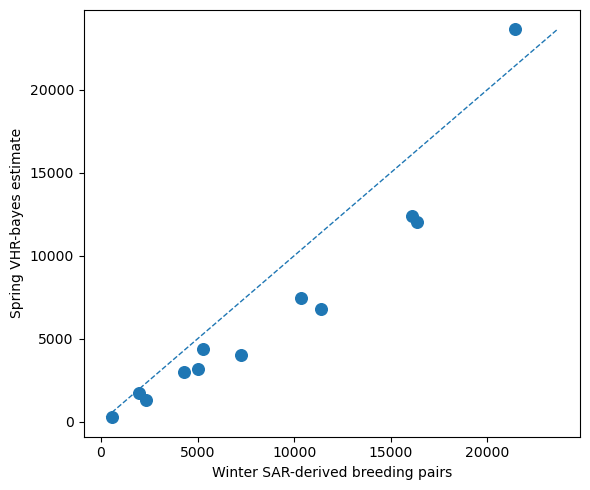

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

plt.scatter(
    comparison['sar_breeding_pairs'],
    comparison['vhr_bayes'],
    s=70
)

# 1:1 line
lims = [
    min(comparison['sar_breeding_pairs'].min(), comparison['vhr_bayes'].min()),
    max(comparison['sar_breeding_pairs'].max(), comparison['vhr_bayes'].max())
]

plt.plot(lims, lims, '--', linewidth=1)

plt.xlabel('Winter SAR-derived breeding pairs')
plt.ylabel('Spring VHR-bayes estimate')
plt.tight_layout()
plt.show()

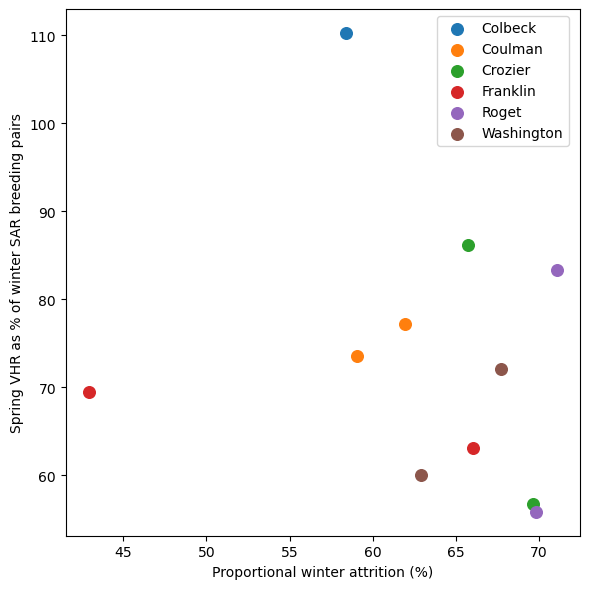

In [29]:
#Plotting the relationship between proportional winter attrition and ratio of spring vhr to sar bp

analysis_model['vhr_as_percent_sar_bp'] = (
    analysis_model['vhr_bayes'] /
    analysis_model['sar_breeding_pairs']
) * 100


fig, ax = plt.subplots(figsize=(6, 6))

for colony in analysis_model['colony'].unique():

    subset = analysis_model[
        analysis_model['colony'] == colony
    ]

    ax.scatter(
        subset['proportional_attrition'] * 100,
        subset['vhr_as_percent_sar_bp'],
        label=colony,
        s=70
    )

ax.set_xlabel('Proportional winter attrition (%)')
ax.set_ylabel('Spring VHR as % of winter SAR breeding pairs')

ax.legend(
    bbox_to_anchor=(0.85, 1),
    loc='upper center'
)

plt.tight_layout()

plt.savefig(os.path.join(INPUTPATH, "Results/VHR_percentBP_attrition.png"),
           bbox_inches="tight", dpi=600)

plt.show()





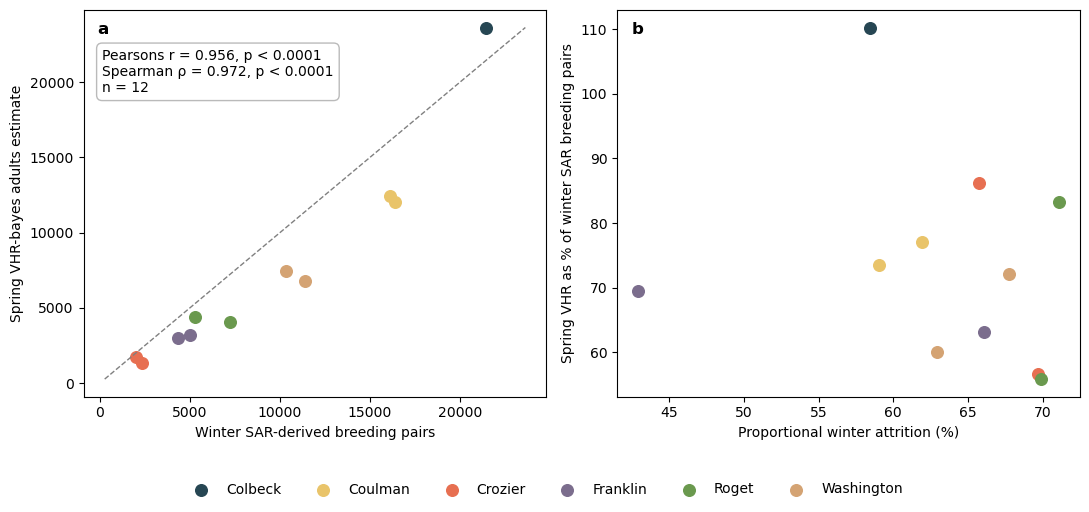

In [78]:
#Combining the above two plots in to a 2 panel with colony colours

import matplotlib.pyplot as plt
import os

# ---------------------------------------------------------
# Colony colours — same colours used across both panels
# ---------------------------------------------------------

colonies = sorted(analysis_model['colony'].unique())

cmap = plt.cm.tab10
colony_colors = {
    colony: cmap(i)
    for i, colony in enumerate(colonies)
}


# ---------------------------------------------------------
# Calculate VHR as % of SAR-bp
# ---------------------------------------------------------

analysis_model['vhr_as_percent_sar_bp'] = (
    analysis_model['vhr_bayes'] /
    analysis_model['sar_breeding_pairs']
) * 100


# ---------------------------------------------------------
# Two-panel figure
# ---------------------------------------------------------

fig, axes = plt.subplots(
    1, 2,
    figsize=(11, 5)
)

ax1, ax2 = axes

# ---------------------------------------------------------
# Colony colours — keep these consistent across figures
# ---------------------------------------------------------

colony_colors = {
    "Beaufort": "#007C83",
    "Colbeck": "#264653",
    "Coulman": "#E9C46A",
    "Crozier": "#E76F51",
    "Franklin": "#7B6D8D",
    "Roget": "#6A994E",
    "Washington": "#D4A373"
}


# =========================================================
# Panel A — SAR-bp vs VHR-bayes
# =========================================================

for colony in colonies:

    subset = winter_spring[
        winter_spring['colony'] == colony
    ].dropna(
        subset=['sar_breeding_pairs', 'vhr_bayes']
    )

    ax1.scatter(
        subset['sar_breeding_pairs'],
        subset['vhr_bayes'],
        color=colony_colors[colony],
        label=colony,
        s=70
    )


# 1:1 line
lims = [
    min(
        winter_spring['sar_breeding_pairs'].min(),
        winter_spring['vhr_bayes'].min()
    ),
    max(
        winter_spring['sar_breeding_pairs'].max(),
        winter_spring['vhr_bayes'].max()
    )
]

ax1.text(
    0.04, 0.90,
    'Pearsons r = 0.956, p < 0.0001\n'
    'Spearman ρ = 0.972, p < 0.0001\n'
    'n = 12',
    transform=ax1.transAxes,
    ha='left',
    va='top',
    fontsize=10,
    bbox=dict(
        boxstyle='round,pad=0.4',
        facecolor='white',
        edgecolor='0.7',
        alpha=0.9
    )
)


ax1.plot(
    lims,
    lims,
    '--',
    color='0.5',
    linewidth=1
)

ax1.set_xlabel('Winter SAR-derived breeding pairs')
ax1.set_ylabel('Spring VHR-bayes adults estimate')

ax1.text(
    0.03, 0.97,
    'a',
    transform=ax1.transAxes,
    ha='left',
    va='top',
    fontsize=12,
    fontweight='bold'
)


# =========================================================
# Panel B — Attrition vs VHR/SAR-bp
# =========================================================

for colony in colonies:

    subset = analysis_model[
        analysis_model['colony'] == colony
    ]

    ax2.scatter(
        subset['proportional_attrition'] * 100,
        subset['vhr_as_percent_sar_bp'],
        color=colony_colors[colony],
        s=70,
        label=colony
    )

ax2.set_xlabel('Proportional winter attrition (%)')
ax2.set_ylabel(
    'Spring VHR as % of winter SAR breeding pairs'
)

ax2.text(
    0.03, 0.97,
    'b',
    transform=ax2.transAxes,
    ha='left',
    va='top',
    fontsize=12,
    fontweight='bold'
)


# ---------------------------------------------------------
# Shared legend
# ---------------------------------------------------------

handles, labels = ax1.get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.05),
    ncol=7,
    frameon=False
)


plt.tight_layout(rect=[0, 0.08, 1, 1])


# ---------------------------------------------------------
# Save
# ---------------------------------------------------------

plt.savefig(
    os.path.join(
        INPUTPATH,
        "Results/VHR_SARbp_relationships.png"
    ),
    bbox_inches='tight',
    dpi=600
)

plt.show()

## The extremely small sample size is an issue (n = 11)

This means that a model will only be be exploratory, not definitive

## The analysis below answers a different question and wont be progressed 

Also, we cant use the ratio as the rerponse the sar-bp as a predictor as they are derived from each other, so it makes no sense. I will shelve this analysis and move on to the last step. 

In [47]:
#This model asks the question, whether greater winter attrition leads to a smaller proportion of the winter breeding population being present by the spring VHR estimate

analysis_model['spring_winter_ratio'] = (
    analysis_model['vhr_bayes'] /
    analysis_model['sar_breeding_pairs']
)

ratio_model = smf.mixedlm(
    "spring_winter_ratio ~ attrition_scaled",
    data=analysis_model,
    groups=analysis_model["colony"],
    vc_formula={"year": "0 + C(year)"}
).fit(
    reml=False,
    method="lbfgs"
)

print(ratio_model.summary())

              Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: spring_winter_ratio
No. Observations: 11      Method:             ML                 
No. Groups:       6       Scale:              0.0110             
Min. group size:  1       Log-Likelihood:     5.3620             
Max. group size:  2       Converged:          Yes                
Mean group size:  1.8                                            
------------------------------------------------------------------
                   Coef.   Std.Err.    z     P>|z|  [0.025  0.975]
------------------------------------------------------------------
Intercept           0.734     0.037  19.994  0.000   0.662   0.806
attrition_scaled   -0.030     0.026  -1.151  0.250  -0.080   0.021
year Var            0.011                                         



/tmp/ipykernel_768969/4161951137.py:13: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  ).fit(


In [49]:
analysis_model[
    ['colony', 'year', 'spring_winter_ratio',
     'sar_breeding_pairs', 'vhr_bayes',
     'proportional_attrition']
].sort_values(['colony', 'year'])

,colony,year,spring_winter_ratio,sar_breeding_pairs,vhr_bayes,proportional_attrition
0,Colbeck,2025,1.102725,21418.41,23618.61000,0.584194
1,Coulman,2024,0.735569,16376.19,12045.81618,0.590640
2,Coulman,2025,0.771365,16088.12,12409.81000,0.619320
3,Crozier,2024,0.566953,2349.79,1332.22000,0.696458
4,Crozier,2025,0.861699,1990.66,1715.35000,0.657187
5,Franklin,2024,0.630730,5029.93,3172.53000,0.660442
6,Franklin,2025,0.694296,4318.43,2998.27000,0.429463
7,Roget,2024,0.832871,5261.45,4382.11000,0.710740
8,Roget,2025,0.558411,7252.01,4049.60000,0.698607
9,Washington,2024,0.721208,10341.24,7458.19000,0.677499


In [50]:
print(analysis_model['spring_winter_ratio'].describe())
print("\nMissing:")
print(analysis_model['spring_winter_ratio'].isna().sum())

print("\nUnique values:")
print(analysis_model['spring_winter_ratio'].nunique())

print("\nColony counts:")
print(analysis_model.groupby('colony').size())

count    11.000000
mean      0.734157
std       0.158922
min       0.558411
25%       0.615317
50%       0.721208
75%       0.802118
max       1.102725
Name: spring_winter_ratio, dtype: float64

Missing:
0

Unique values:
11

Colony counts:
colony
Colbeck       1
Coulman       2
Crozier       2
Franklin      2
Roget         2
Washington    2
dtype: int64


In [51]:
analysis_model = analysis_model.copy()

analysis_model['spring_winter_ratio'] = (
    analysis_model['vhr_bayes'] /
    analysis_model['sar_breeding_pairs']
)

print(
    analysis_model[
        ['colony', 'year', 'vhr_bayes',
         'sar_breeding_pairs', 'spring_winter_ratio']
    ]
)

        colony  year    vhr_bayes  sar_breeding_pairs  spring_winter_ratio
0      Colbeck  2025  23618.61000            21418.41             1.102725
1      Coulman  2024  12045.81618            16376.19             0.735569
2      Coulman  2025  12409.81000            16088.12             0.771365
3      Crozier  2024   1332.22000             2349.79             0.566953
4      Crozier  2025   1715.35000             1990.66             0.861699
5     Franklin  2024   3172.53000             5029.93             0.630730
6     Franklin  2025   2998.27000             4318.43             0.694296
7        Roget  2024   4382.11000             5261.45             0.832871
8        Roget  2025   4049.60000             7252.01             0.558411
9   Washington  2024   7458.19000            10341.24             0.721208
10  Washington  2025   6819.64000            11367.90             0.599903


## Next we are looking at the percentage difference between winter obs and spring vhr 



In [113]:
#calculating absolute percent difference

analysis_model['error_sar_peak'] = (
    abs(
        (analysis_model['vhr_bayes'] - analysis_model['sar_peak'])
        / analysis_model['sar_peak']
    ) * 100
)

analysis_model['error_sar_low'] = (
    abs(
        (analysis_model['vhr_bayes'] - analysis_model['sar_low'])
        / analysis_model['sar_low']
    ) * 100
)

analysis_model['error_sar_bp'] = (
    abs(
        (analysis_model['vhr_bayes'] - analysis_model['sar_breeding_pairs'])
        / analysis_model['sar_breeding_pairs']
    ) * 100
)

In [114]:
#compare the mean absolute percent difference

comparison = pd.DataFrame({
    'SAR peak': [
        analysis_model['error_sar_peak'].mean(),
        analysis_model['error_sar_peak'].median()
    ],
    'SAR low': [
        analysis_model['error_sar_low'].mean(),
        analysis_model['error_sar_low'].median()
    ],
    'SAR breeding pairs': [
        analysis_model['error_sar_bp'].mean(),
        analysis_model['error_sar_bp'].median()
    ]
}, index=['mean_absolute_difference_%',
          'median_absolute_difference_%'])

comparison

#lower equals closer to the spring vhr estimate
#this tells us the sar low is closest to the vhr

,SAR peak,SAR low,SAR breeding pairs
mean_absolute_difference_%,63.004548,21.433870,28.451988
median_absolute_difference_%,61.893221,18.048716,27.879152


In [115]:
#Let's model it 

import statsmodels.formula.api as smf

model_peak = smf.mixedlm(
    "vhr_bayes ~ sar_peak",
    data=analysis_model,
    groups=analysis_model["colony"],
    vc_formula={"year": "0 + C(year)"}
).fit()

model_low = smf.mixedlm(
    "vhr_bayes ~ sar_low",
    data=analysis_model,
    groups=analysis_model["colony"],
    vc_formula={"year": "0 + C(year)"}
).fit()

model_bp = smf.mixedlm(
    "vhr_bayes ~ sar_breeding_pairs",
    data=analysis_model,
    groups=analysis_model["colony"],
    vc_formula={"year": "0 + C(year)"}
).fit()

/tmp/ipykernel_1708/1673655351.py:10: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  ).fit()
/tmp/ipykernel_1708/1673655351.py:17: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  ).fit()
/tmp/ipykernel_1708/1673655351.py:24: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  ).fit()


In [116]:
print("SAR peak")
print(model_peak.summary())

print("\nSAR low")
print(model_low.summary())

print("\nSAR breeding pairs")
print(model_bp.summary())

SAR peak
             Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   vhr_bayes   
No. Observations:   11        Method:               REML        
No. Groups:         6         Scale:                2604456.5967
Min. group size:    1         Log-Likelihood:       -94.0755    
Max. group size:    2         Converged:            Yes         
Mean group size:    1.8                                         
----------------------------------------------------------------
             Coef.    Std.Err.    z    P>|z|   [0.025    0.975] 
----------------------------------------------------------------
Intercept   -2408.388   80.036 -30.091 0.000 -2565.255 -2251.521
sar_peak        0.538    0.029  18.369 0.000     0.481     0.596
year Var  2604456.597                                           


SAR low
            Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  vhr_bayes   
No. Observations:  11       Method:   

In [117]:
from sklearn.metrics import mean_squared_error
import numpy as np

models = {
    'SAR peak': model_peak,
    'SAR low': model_low,
    'SAR breeding pairs': model_bp
}

rmse = {}

for name, model in models.items():

    predictions = model.fittedvalues

    rmse[name] = np.sqrt(
        mean_squared_error(
            analysis_model['vhr_bayes'],
            predictions
        )
    )

rmse

{'SAR peak': np.float64(1032.2109846483993),
 'SAR low': np.float64(898.0966739903569),
 'SAR breeding pairs': np.float64(954.6690886948973)}

## All that agrees that there is highest agreement between low sar obs and vhr obs. 

Which makes sense as they are the closest in time 

____

## Analysis #3 | Chicks 

### Next up I want to investigate how our sar-bp, vhr-estimates, and chicks 

For this analysis, we want to look at only the sites that have all three metrics: chicks, vhr and sar-bp 

- Crozier 2024 and 2025 
- Coulman (important note for low in 2025)
- Washington 2024 and 2025
- Roget 2024 and 2025 

### So we have 7 observations (or 8 incl. Coulman 2025)




In [57]:
# ---------------------------------------------------------
# Chick counts
# ---------------------------------------------------------

chicks = (
    df_RossSea[
        (df_RossSea['method'] == 'chicks') &
        (df_RossSea['year'].isin([2024, 2025]))
    ][
        ['colony', 'year', 'count']
    ]
    .rename(columns={
        'count': 'chick_count'
    })
)

chicks

,colony,year,chick_count
2,Coulman,2024,21242.0
3,Coulman,2025,6686.0
4,Crozier,2024,2773.0
5,Crozier,2025,2782.0
6,Roget,2025,7736.0
7,Roget,2024,7397.0
8,Washington,2024,13803.0
9,Washington,2025,14297.0


In [58]:
# ---------------------------------------------------------
# SAR-bp counts
# ---------------------------------------------------------

SAR_bp = (
    df_RossSea[
        (df_RossSea['method'] == 'SAR-bp') &
        (df_RossSea['year'].isin([2024, 2025]))
    ][
        ['colony', 'year', 'count']
    ]
    .rename(columns={
        'count': 'sar-bp_count'
    })
)
SAR_bp

,colony,year,sar-bp_count
118,Beaufort,2025,563.95
119,Colbeck,2025,21418.41
120,Coulman,2025,16088.12
121,Coulman,2024,16376.19
122,Crozier,2025,1990.66
123,Crozier,2024,2349.79
124,Franklin,2025,4318.43
125,Franklin,2024,5029.93
126,Roget,2025,7252.01
127,Roget,2024,5261.45


In [59]:
# ---------------------------------------------------------
# VHR-bayes counts
# ---------------------------------------------------------

VHR_bayes = (
    df_RossSea[
        (df_RossSea['method'] == 'VHR-bayes') &
        (df_RossSea['year'].isin([2024, 2025]))
    ][
        ['colony', 'year', 'count']
    ]
    .rename(columns={
        'count': 'vhr-bayes_count'
    })
)
VHR_bayes

,colony,year,vhr-bayes_count
130,Beaufort,2024,293.27000
131,Beaufort,2025,273.90000
132,Colbeck,2024,23821.74000
133,Colbeck,2025,23618.61000
134,Coulman,2025,12409.81000
135,Coulman,2025,8850.12000
136,Coulman,2025,10089.04000
137,Coulman,2024,12045.81618
138,Crozier,2024,1332.22000
139,Crozier,2025,1715.35000


In [60]:
## Now we want to combine them
combined = (
    SAR_bp
    .merge(
        chicks,
        on=['colony', 'year'],
        how='left'
    )
)
combined

,colony,year,sar-bp_count,chick_count
0,Beaufort,2025,563.95,NaN
1,Colbeck,2025,21418.41,NaN
2,Coulman,2025,16088.12,6686.0
3,Coulman,2024,16376.19,21242.0
4,Crozier,2025,1990.66,2782.0
5,Crozier,2024,2349.79,2773.0
6,Franklin,2025,4318.43,NaN
7,Franklin,2024,5029.93,NaN
8,Roget,2025,7252.01,7736.0
9,Roget,2024,5261.45,7397.0


In [61]:
## Now we want to combine them again
combined_2 = (
    combined
    .merge(
        VHR_bayes,
        on=['colony', 'year'],
        how='left'
    )
)
combined_2

,colony,year,sar-bp_count,chick_count,vhr-bayes_count
0,Beaufort,2025,563.95,NaN,273.90000
1,Colbeck,2025,21418.41,NaN,23618.61000
2,Coulman,2025,16088.12,6686.0,12409.81000
3,Coulman,2025,16088.12,6686.0,8850.12000
4,Coulman,2025,16088.12,6686.0,10089.04000
5,Coulman,2024,16376.19,21242.0,12045.81618
6,Crozier,2025,1990.66,2782.0,1715.35000
7,Crozier,2024,2349.79,2773.0,1332.22000
8,Franklin,2025,4318.43,NaN,2998.27000
9,Franklin,2024,5029.93,NaN,3172.53000


### I need to remove coulman island 2025 others, and use those in the case study part at the end 


In [62]:
combined_3 = combined_2[
    ~(
        (combined_2['colony'] == 'Coulman') &
        (combined_2['year'] == 2025) &
        (combined_2['vhr-bayes_count'].isin([8850.12, 10089.04]))
    )
].copy()

In [64]:
print(
    combined_3[
        (combined_3['colony'] == 'Coulman') &
        (combined_3['year'] == 2025)
    ]
)

print(
    combined_3
    .groupby(['colony', 'year'])
    .size()
)

    colony  year  sar-bp_count  chick_count  vhr-bayes_count
2  Coulman  2025      16088.12       6686.0         12409.81
colony      year
Beaufort    2025    1
Colbeck     2025    1
Coulman     2024    1
            2025    1
Crozier     2024    1
            2025    1
Franklin    2024    1
            2025    1
Roget       2024    1
            2025    1
Washington  2024    1
            2025    1
dtype: int64


## Ok and now we compare each different data type against each other 

In [65]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr


def compare_methods(df, method_a, method_b, label):
    
    # Keep only complete pairs
    comparison = df[[method_a, method_b]].dropna().copy()
    
    x = comparison[method_a].astype(float)
    y = comparison[method_b].astype(float)
    
    # Differences
    difference = x - y
    absolute_difference = np.abs(difference)
    
    # Symmetric percentage difference
    # Uses the mean of the two methods as the denominator
    percentage_difference = (
        absolute_difference /
        ((np.abs(x) + np.abs(y)) / 2)
    ) * 100
    
    # Ratio
    ratio = x / y
    
    # Correlations
    pearson_r, pearson_p = pearsonr(x, y)
    spearman_rho, spearman_p = spearmanr(x, y)
    
    return {
        'comparison': label,
        'n': len(comparison),
        
        'mean_A': x.mean(),
        'mean_B': y.mean(),
        
        'mean_difference': difference.mean(),
        'MAE': absolute_difference.mean(),
        'MAPD': percentage_difference.mean(),
        
        'mean_ratio': ratio.mean(),
        'median_ratio': ratio.median(),
        
        'Pearson_r': pearson_r,
        'Pearson_p': pearson_p,
        
        'Spearman_rho': spearman_rho,
        'Spearman_p': spearman_p
    }


results = pd.DataFrame([
    
    compare_methods(
        combined_3,
        'chick_count',
        'sar-bp_count',
        'Chicks vs SAR-bp'
    ),
    
    compare_methods(
        combined_3,
        'chick_count',
        'vhr-bayes_count',
        'Chicks vs VHR-bayes'
    ),
    
    compare_methods(
        combined_3,
        'vhr-bayes_count',
        'sar-bp_count',
        'VHR-bayes vs SAR-bp'
    )
])


print(results.round(3))

            comparison   n    mean_A    mean_B  mean_difference       MAE  \
0     Chicks vs SAR-bp   8  9589.500  8878.420          711.080  3061.610   
1  Chicks vs VHR-bayes   8  9589.500  6276.592         3312.908  4743.860   
2  VHR-bayes vs SAR-bp  12  6689.671  8529.840        -1840.169  2206.869   

     MAPD  mean_ratio  median_ratio  Pearson_r  Pearson_p  Spearman_rho  \
0  31.228       1.169         1.277      0.741      0.035         0.738   
1  59.635       1.694         1.807      0.685      0.061         0.595   
2  37.010       0.713         0.708      0.956      0.000         0.972   

   Spearman_p  
0       0.037  
1       0.120  
2       0.000  


In [68]:
## make it a cleaner table: 

comparison_summary = results[
    [
        'comparison',
        'n',
        'mean_difference',
        'MAE',
        'MAPD',
        'mean_ratio',
        'Pearson_r',
        'Pearson_p',
        'Spearman_rho',
        'Spearman_p'
    ]
].copy()


comparison_summary = comparison_summary.rename(columns={
    'comparison': 'Comparison',
    'n': 'n',
    'mean_difference': 'Mean difference',
    'MAE': 'MAE',
    'MAPD': 'MAPD (%)',
    'mean_ratio': 'Mean ratio',
    'Pearson_r': 'Pearson r',
    'Pearson_p': 'Pearson p',
    'Spearman_rho': 'Spearman ρ',
    'Spearman_p': 'Spearman p'
})

print(comparison_summary.round(3))

            Comparison   n  Mean difference       MAE  MAPD (%)  Mean ratio  \
0     Chicks vs SAR-bp   8          711.080  3061.610    31.228       1.169   
1  Chicks vs VHR-bayes   8         3312.908  4743.860    59.635       1.694   
2  VHR-bayes vs SAR-bp  12        -1840.169  2206.869    37.010       0.713   

   Pearson r  Pearson p  Spearman ρ  Spearman p  
0      0.741      0.035       0.738       0.037  
1      0.685      0.061       0.595       0.120  
2      0.956      0.000       0.972       0.000  


In [76]:
# correlation matrix 
methods = [
    'chick_count',
    'sar-bp_count',
    'vhr-bayes_count'
]

correlation_matrix = combined_3[methods].corr(method='pearson')


spearman_matrix = combined_3[methods].corr(method='spearman')


method_labels = {
    'chick_count': 'Chicks',
    'sar-bp_count': 'SAR-bp',
    'vhr-bayes_count': 'VHR-bayes'
}

correlation_matrix = correlation_matrix.rename(
    index=method_labels,
    columns=method_labels
)

spearman_matrix = spearman_matrix.rename(
    index=method_labels,
    columns=method_labels
)

print(correlation_matrix.round(3))
print(spearman_matrix.round(3))

           Chicks  SAR-bp  VHR-bayes
Chicks      1.000   0.741      0.685
SAR-bp      0.741   1.000      0.956
VHR-bayes   0.685   0.956      1.000
           Chicks  SAR-bp  VHR-bayes
Chicks      1.000   0.738      0.595
SAR-bp      0.738   1.000      0.972
VHR-bayes   0.595   0.972      1.000


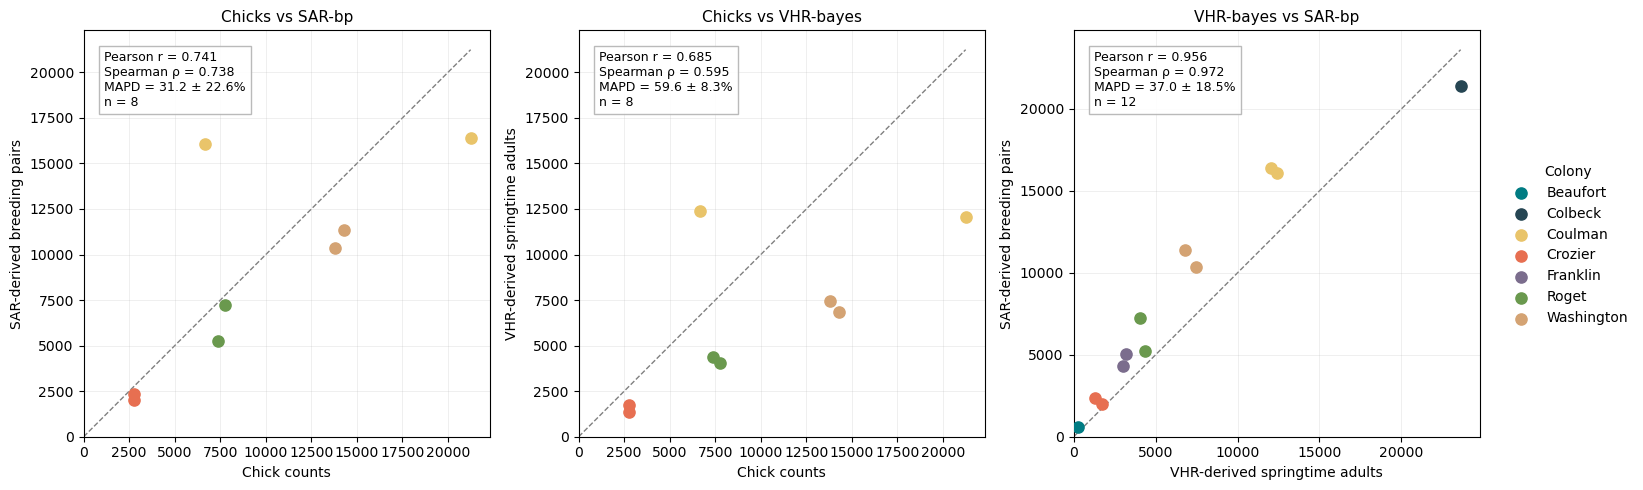

In [79]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# ---------------------------------------------------------
# Colony colours — keep these consistent across figures
# ---------------------------------------------------------

colony_colors = {
    "Beaufort": "#007C83",
    "Colbeck": "#264653",
    "Coulman": "#E9C46A",
    "Crozier": "#E76F51",
    "Franklin": "#7B6D8D",
    "Roget": "#6A994E",
    "Washington": "#D4A373"
}


# ---------------------------------------------------------
# Pairwise comparisons
# ---------------------------------------------------------

pairs = [
    (
        'chick_count',
        'sar-bp_count',
        'Chick counts',
        'SAR-derived breeding pairs',
        'Chicks vs SAR-bp'
    ),
    (
        'chick_count',
        'vhr-bayes_count',
        'Chick counts',
        'VHR-derived springtime adults',
        'Chicks vs VHR-bayes'
    ),
    (
        'vhr-bayes_count',
        'sar-bp_count',
        'VHR-derived springtime adults',
        'SAR-derived breeding pairs',
        'VHR-bayes vs SAR-bp'
    )
]


# ---------------------------------------------------------
# Figure
# ---------------------------------------------------------

fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 5)
)


for ax, (x_col, y_col, x_label, y_label, title) in zip(axes, pairs):

    df_plot = combined_3[
        [x_col, y_col, 'colony', 'year']
    ].dropna().copy()

    x = df_plot[x_col].astype(float)
    y = df_plot[y_col].astype(float)

    # -----------------------------------------------------
    # 1:1 line
    # -----------------------------------------------------

    max_value = max(x.max(), y.max())

    ax.plot(
        [0, max_value],
        [0, max_value],
        linestyle='--',
        linewidth=1,
        color='0.5',
        zorder=1
    )

    # -----------------------------------------------------
    # Plot colonies
    # -----------------------------------------------------

    for colony, group in df_plot.groupby('colony'):

        ax.scatter(
            group[x_col],
            group[y_col],
            color=colony_colors.get(colony, '0.5'),
            s=65,
            label=colony,
            zorder=3
        )

    # -----------------------------------------------------
    # Statistics
    # -----------------------------------------------------

    pearson_r, pearson_p = pearsonr(x, y)
    spearman_rho, spearman_p = spearmanr(x, y)

    # Symmetric percentage difference
    percentage_difference = (
        np.abs(x - y) /
        ((np.abs(x) + np.abs(y)) / 2)
    ) * 100

    mapd = percentage_difference.mean()
    mapd_sd = percentage_difference.std(ddof=1)

    mapd_se = mapd_sd / np.sqrt(len(percentage_difference))

    # -----------------------------------------------------
    # Statistics annotation
    # -----------------------------------------------------

    ax.text(
        0.05,
        0.95,
        f'Pearson r = {pearson_r:.3f}\n'
        f'Spearman ρ = {spearman_rho:.3f}\n'
        f'MAPD = {mapd:.1f} ± {mapd_sd:.1f}%\n'
        f'n = {len(df_plot)}',
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=9,
        bbox=dict(
            boxstyle='square,pad=0.4',
            facecolor='white',
            edgecolor='0.7',
            alpha=0.9
        )
    )

    # -----------------------------------------------------
    # Labels
    # -----------------------------------------------------

    ax.set_title(title, fontsize=11)

    ax.set_xlabel(
        x_label,
        fontsize=10
    )

    ax.set_ylabel(
        y_label,
        fontsize=10
    )

    # -----------------------------------------------------
    # Axes
    # -----------------------------------------------------

    ax.set_xlim(0, max_value * 1.05)
    ax.set_ylim(0, max_value * 1.05)

    ax.grid(
        alpha=0.2,
        linewidth=0.7
    )


# ---------------------------------------------------------
# Shared legend
# ---------------------------------------------------------

handles, labels = axes[-1].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc='center left',
    bbox_to_anchor=(1.0, 0.5),
    frameon=False,
    title='Colony'
)

plt.tight_layout()

# ---------------------------------------------------------
# Save
# ---------------------------------------------------------

plt.savefig(
    os.path.join(
        INPUTPATH,
        "Results/allThreeMethods_relationships.png"
    ),
    bbox_inches='tight',
    dpi=600
)



plt.show()

___ 

## As this plot includes a repeat from above, I think I should instead do a four panel plot with all four comparisons 

- chicks vs sar 
- chicks vs vhr 
- sar vs vhr 
- and finally ratio of sar-vhr against winter attrition 



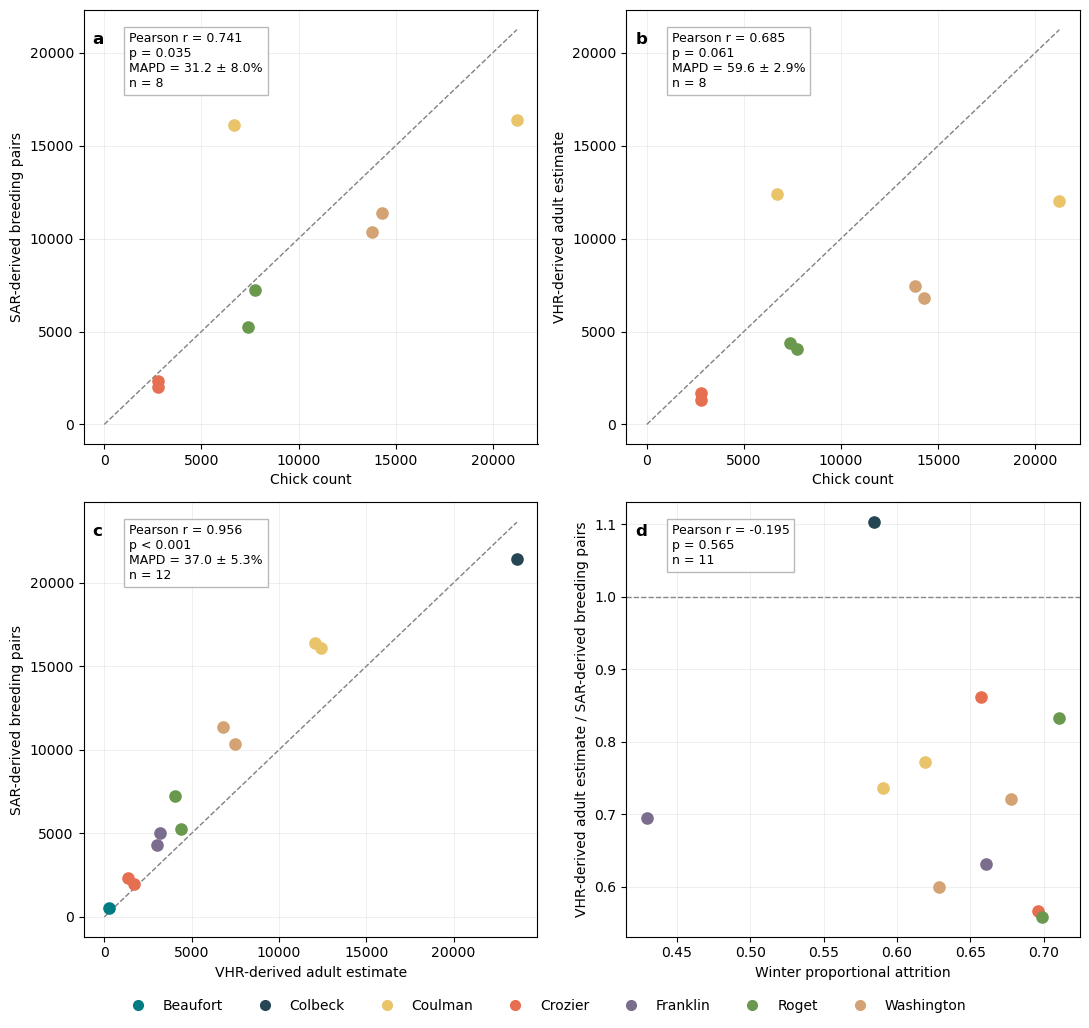

In [111]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# ---------------------------------------------------------
# Colony colours — matching the previous multipanel plot
# ---------------------------------------------------------

colony_colors = {
    "Beaufort": "#007C83",
    "Colbeck": "#264653",
    "Coulman": "#E9C46A",
    "Crozier": "#E76F51",
    "Franklin": "#7B6D8D",
    "Roget": "#6A994E",
    "Washington": "#D4A373"
}


# ---------------------------------------------------------
# Set up 2 x 2 figure
# ---------------------------------------------------------

fig, axes = plt.subplots(
    2, 2,
    figsize=(11, 10)
)

axes = axes.flatten()


# =========================================================
# PANEL A — Chicks vs SAR-bp
# =========================================================

ax = axes[0]

df_plot = combined_3[
    ['chick_count', 'sar-bp_count', 'colony', 'year']
].dropna().copy()

x = df_plot['chick_count'].astype(float)
y = df_plot['sar-bp_count'].astype(float)

max_value = max(x.max(), y.max())

# 1:1 line
ax.plot(
    [0, max_value],
    [0, max_value],
    linestyle='--',
    linewidth=1,
    color='0.5',
    zorder=1
)

# Points
for colony, group in df_plot.groupby('colony'):
    ax.scatter(
        group['chick_count'],
        group['sar-bp_count'],
        color=colony_colors.get(colony, '0.5'),
        s=65,
        label=colony,
        zorder=3
    )

pearson_r, pearson_p = pearsonr(x, y)
#spearman_rho, spearman_p = spearmanr(x, y)
p_text = f'p = {pearson_p:.3f}' if pearson_p >= 0.001 else 'p < 0.001'

percentage_difference = (
    np.abs(x - y) /
    ((np.abs(x) + np.abs(y)) / 2)
) * 100

mapd = percentage_difference.mean()
mapd_se = percentage_difference.std(ddof=1) / np.sqrt(len(percentage_difference))

ax.text(
    0.1, 0.95,
    f'Pearson r = {pearson_r:.3f}\n'
    f'{p_text}\n'
#    f'Spearman ρ = {spearman_rho:.3f}\n'
    f'MAPD = {mapd:.1f} ± {mapd_se:.1f}%\n'
    f'n = {len(df_plot)}',
    transform=ax.transAxes,
    ha='left',
    va='top',
    fontsize=9,
    bbox=dict(
        boxstyle='square,pad=0.4',
        facecolor='white',
        edgecolor='0.7',
        alpha=0.9
    )
)

ax.set_xlabel('Chick count')
ax.set_ylabel('SAR-derived breeding pairs')


# =========================================================
# PANEL B — Chicks vs VHR-bayes
# =========================================================

ax = axes[1]

df_plot = combined_3[
    ['chick_count', 'vhr-bayes_count', 'colony', 'year']
].dropna().copy()

x = df_plot['chick_count'].astype(float)
y = df_plot['vhr-bayes_count'].astype(float)

max_value = max(x.max(), y.max())

ax.plot(
    [0, max_value],
    [0, max_value],
    linestyle='--',
    linewidth=1,
    color='0.5',
    zorder=1
)

for colony, group in df_plot.groupby('colony'):
    ax.scatter(
        group['chick_count'],
        group['vhr-bayes_count'],
        color=colony_colors.get(colony, '0.5'),
        s=65,
        zorder=3
    )

pearson_r, pearson_p = pearsonr(x, y)
#spearman_rho, spearman_p = spearmanr(x, y)
p_text = f'p = {pearson_p:.3f}' if pearson_p >= 0.001 else 'p < 0.001'

percentage_difference = (
    np.abs(x - y) /
    ((np.abs(x) + np.abs(y)) / 2)
) * 100

mapd = percentage_difference.mean()
mapd_se = percentage_difference.std(ddof=1) / np.sqrt(len(percentage_difference))

ax.text(
    0.1, 0.95,
    f'Pearson r = {pearson_r:.3f}\n'
    f'{p_text}\n'
#    f'Spearman ρ = {spearman_rho:.3f}\n'
    f'MAPD = {mapd:.1f} ± {mapd_se:.1f}%\n'
    f'n = {len(df_plot)}',
    transform=ax.transAxes,
    ha='left',
    va='top',
    fontsize=9,
    bbox=dict(
        boxstyle='square,pad=0.4',
        facecolor='white',
        edgecolor='0.7',
        alpha=0.9
    )
)

ax.set_xlabel('Chick count')
ax.set_ylabel('VHR-derived adult estimate')


# =========================================================
# PANEL C — VHR-bayes vs SAR-bp
# =========================================================

ax = axes[2]

df_plot = combined_3[
    ['vhr-bayes_count', 'sar-bp_count', 'colony', 'year']
].dropna().copy()

x = df_plot['vhr-bayes_count'].astype(float)
y = df_plot['sar-bp_count'].astype(float)

max_value = max(x.max(), y.max())

ax.plot(
    [0, max_value],
    [0, max_value],
    linestyle='--',
    linewidth=1,
    color='0.5',
    zorder=1
)

for colony, group in df_plot.groupby('colony'):
    ax.scatter(
        group['vhr-bayes_count'],
        group['sar-bp_count'],
        color=colony_colors.get(colony, '0.5'),
        s=65,
        zorder=3
    )

pearson_r, pearson_p = pearsonr(x, y)
#spearman_rho, spearman_p = spearmanr(x, y)
p_text = f'p = {pearson_p:.3f}' if pearson_p >= 0.001 else 'p < 0.001'

percentage_difference = (
    np.abs(x - y) /
    ((np.abs(x) + np.abs(y)) / 2)
) * 100

mapd = percentage_difference.mean()
mapd_se = percentage_difference.std(ddof=1) / np.sqrt(len(percentage_difference))

ax.text(
    0.1, 0.95,
    f'Pearson r = {pearson_r:.3f}\n'
    f'{p_text}\n'
 #   f'Spearman ρ = {spearman_rho:.3f}\n'
    f'MAPD = {mapd:.1f} ± {mapd_se:.1f}%\n'
    f'n = {len(df_plot)}',
    transform=ax.transAxes,
    ha='left',
    va='top',
    fontsize=9,
    bbox=dict(
        boxstyle='square,pad=0.4',
        facecolor='white',
        edgecolor='0.7',
        alpha=0.9
    )
)

ax.set_xlabel('VHR-derived adult estimate')
ax.set_ylabel('SAR-derived breeding pairs')


# =========================================================
# PANEL D — VHR/SAR-bp ratio vs winter attrition
# =========================================================

ax = axes[3]

df_plot = analysis_model.copy()

x = df_plot['proportional_attrition'].astype(float)
y = (
    df_plot['vhr_bayes'] /
    df_plot['sar_breeding_pairs']
).astype(float)

# Points
for colony, group in df_plot.groupby('colony'):
    ax.scatter(
        group['proportional_attrition'],
        group['vhr_bayes'] / group['sar_breeding_pairs'],
        color=colony_colors.get(colony, '0.5'),
        s=65,
        zorder=3
    )

# Exact agreement
ax.axhline(
    1,
    linestyle='--',
    linewidth=1,
    color='0.5',
    zorder=1
)

# Correlations
pearson_r, pearson_p = pearsonr(x, y)
#spearman_rho, spearman_p = spearmanr(x, y)
p_text = f'p = {pearson_p:.3f}' if pearson_p >= 0.001 else 'p < 0.001'

ax.text(
    0.1, 0.95,
    f'Pearson r = {pearson_r:.3f}\n'
    f'{p_text}\n'
    f'n = {len(df_plot)}',
    transform=ax.transAxes,
    ha='left',
    va='top',
    fontsize=9,
    bbox=dict(
        boxstyle='square,pad=0.4',
        facecolor='white',
        edgecolor='0.7',
        alpha=0.9
    )
)

ax.set_xlabel('Winter proportional attrition')
ax.set_ylabel('VHR-derived adult estimate / SAR-derived breeding pairs')


# =========================================================
# PANEL LETTERS
# =========================================================

letters = ['a', 'b', 'c', 'd']

for ax, letter in zip(axes, letters):
    ax.text(
        0.02, 0.95,
        letter,
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=12,
        fontweight='bold'
    )

    ax.grid(
        alpha=0.2,
        linewidth=0.7
    )


# =========================================================
# ONE SHARED LEGEND
# =========================================================


legend_handles = [
    Line2D(
        [0], [0],
        marker='o',
        linestyle='None',
        markerfacecolor=color,
        markeredgecolor=color,
        markersize=7,
        label=colony
    )
    for colony, color in colony_colors.items()
]

fig.legend(
    handles=legend_handles,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.03),
    frameon=False, ncol = 7#,
   # title='Colony'
)
plt.tight_layout()


# ---------------------------------------------------------
# Save
# ---------------------------------------------------------

plt.savefig(
    os.path.join(
        INPUTPATH,
        "Results/allfour_relationships.png"
    ),
    bbox_inches='tight',
    dpi=600
)




plt.show()

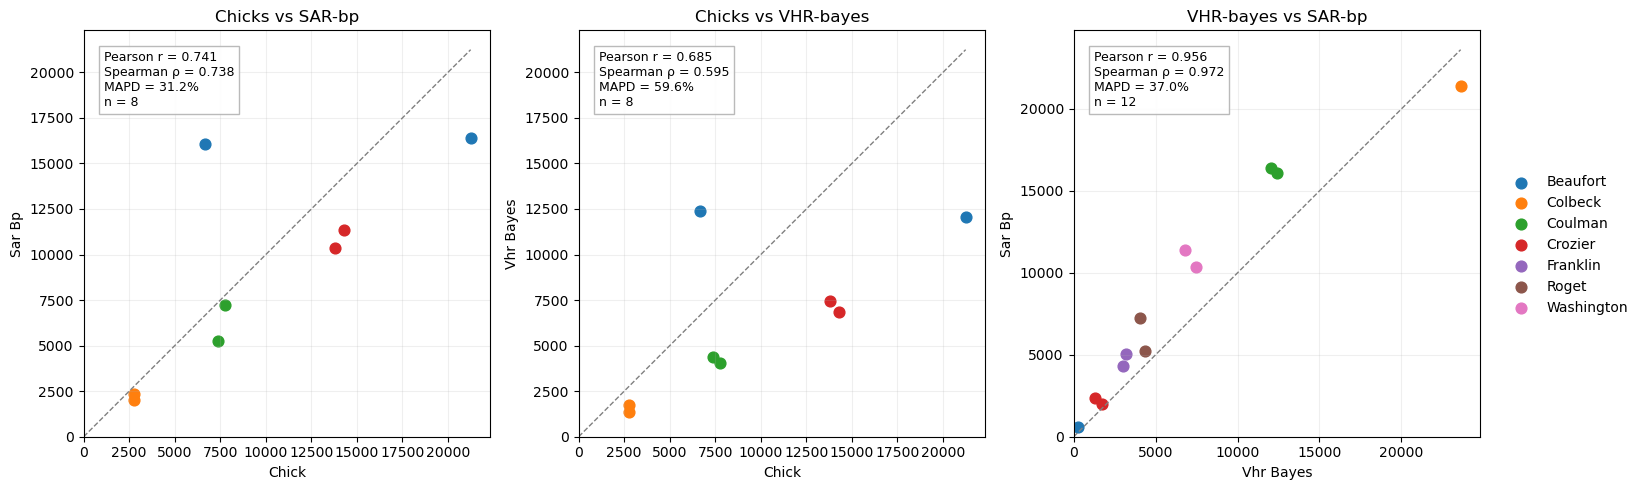

In [75]:
##now we make it a figure 

import matplotlib.pyplot as plt

pairs = [
    ('chick_count', 'sar-bp_count', 'Chicks vs SAR-bp'),
    ('chick_count', 'vhr-bayes_count', 'Chicks vs VHR-bayes'),
    ('vhr-bayes_count', 'sar-bp_count', 'VHR-bayes vs SAR-bp')
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (x_col, y_col, title) in zip(axes, pairs):
    
    df_plot = combined_3[
        [x_col, y_col, 'colony', 'year']
    ].dropna().copy()
    
    x = df_plot[x_col]
    y = df_plot[y_col]
    
    # 1:1 line
    max_value = max(x.max(), y.max())
    ax.plot(
        [0, max_value],
        [0, max_value],
        linestyle='--',
        linewidth=1,
        color='0.5'
    )
    
    # Plot each colony
    for colony, group in df_plot.groupby('colony'):
        ax.scatter(
            group[x_col],
            group[y_col],
            label=colony,
            s=60
        )
    
    # Correlations
    r, p = pearsonr(x, y)
    rho, rho_p = spearmanr(x, y)
    
    # MAPD
    mapd = (
        np.abs(x - y) /
        ((np.abs(x) + np.abs(y)) / 2)
    ).mean() * 100
    
    ax.text(
        0.05, 0.95,
        f'Pearson r = {r:.3f}\n'
        f'Spearman ρ = {rho:.3f}\n'
        f'MAPD = {mapd:.1f}%\n'
        f'n = {len(df_plot)}',
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=9,
        bbox=dict(
            boxstyle='square,pad=0.4',
            facecolor='white',
            edgecolor='0.7',
            alpha=0.9
        )
    )
    
    ax.set_title(title)
    ax.set_xlabel(x_col.replace('_count', '').replace('-', ' ').title())
    ax.set_ylabel(y_col.replace('_count', '').replace('-', ' ').title())
    
    ax.set_xlim(0, max_value * 1.05)
    ax.set_ylim(0, max_value * 1.05)
    
    ax.grid(alpha=0.2)

# One shared legend
handles, labels = axes[-1].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc='center left',
    bbox_to_anchor=(1.0, 0.5),
    frameon=False
)

plt.tight_layout()
plt.show()

____ 

## I think we should redo the chick vs sar-bp analysis here 
### Using only the Ross Sea colonies, from 2024 and 2025
#### And consider whether we want to correct the negaive bias for the locations for the remainder of the analysis.... 


In [124]:
# ok redoing the other analysis from the last paper 

# This code has been taken from the other paper comparing chicks to bp at all sites we had data for in antarctica in 2024 and 2025
# We will run it with coulman 2025 and without and compare


combined_2 #has all the data, we want to get out the chicks and sar-bp data count data

combined_2 = pd.DataFrame(combined_2).dropna(subset=["chick_count"])
combined_2["pct_diff"] = ((combined_2["sar-bp_count"] - combined_2["chick_count"]) /
                       combined_2["chick_count"] * 100).round(1)


#Rerunning the stats without Coulman 2025

# ── Stats ──────────────────────────────────────────────────────────────────
from scipy import stats

#print("\nNote: Coulman 2025 excluded from all performance statistics")
#print(f"      (iceberg-induced chick mortality — n={len(dfComp)} pairs used)")


#Pearsons R 
r_val, p_val = stats.pearsonr(combined_2["sar-bp_count"], combined_2["chick_count"])

#Slope
slope, intercept, r_value, p_value, se = stats.linregress(
    combined_2["chick_count"], combined_2["sar-bp_count"]
)

## Mean absolute percentage error
mape = np.abs(combined_2["pct_diff"]).mean()

# Mean bias and standard deviation
bias = combined_2["pct_diff"].mean()
bias_sd = combined_2["pct_diff"].std(ddof=1)   # Sample SD



print(f"\nModel performance statistics:")
print(f"\nchicks vs SAR-bp w Coulman 2025:")
print(f"  Pearson r:    {r_val:.3f}  (p={p_val:.4f})")
print(f"  R²:           {r_value**2:.3f}")
print(f"  Slope:        {slope:.3f}")
print(f"  MAPE:         {mape:.1f}%")
print(f"  Mean bias:    {bias:.1f}%  "
      f"({'overestimate' if bias > 0 else 'underestimate'})")
print(f"  Mean bias:    {bias:.1f} ± {bias_sd:.1f}%  "
      f"({'overestimate' if bias > 0 else 'underestimate'})")


Model performance statistics:

chicks vs SAR-bp w Coulman 2025:
  Pearson r:    0.507  (p=0.1347)
  R²:           0.257
  Slope:        0.513
  MAPE:         56.9%
  Mean bias:    27.4%  (overestimate)
  Mean bias:    27.4 ± 78.4%  (overestimate)


In [125]:
## Now we want to remove the coulman 2025 

# ok redoing the other analysis from the last paper 

# This code has been taken from the other paper comparing chicks to bp at all sites we had data for in antarctica in 2024 and 2025
# We will run it with coulman 2025 and without and compare


combined_2 #has all the data, we want to get out the chicks and sar-bp data count data

combined_2 = pd.DataFrame(combined_2).dropna(subset=["chick_count"])
combined_2["pct_diff"] = ((combined_2["sar-bp_count"] - combined_2["chick_count"]) /
                       combined_2["chick_count"] * 100).round(1)

# Remove Coulman 2025 — chick count reduction due to iceberg mortality event
# not representative of model performance
combined_3 = combined_2[~((combined_2["colony"] == "Coulman") & 
                   (combined_2["year"] == 2025))].copy()

print(f"Rows after removing Coulman 2025: {len(combined_3)}")



#Rerunning the stats without Coulman 2025

# ── Stats ──────────────────────────────────────────────────────────────────
from scipy import stats

#print("\nNote: Coulman 2025 excluded from all performance statistics")
#print(f"      (iceberg-induced chick mortality — n={len(dfComp)} pairs used)")


#Pearsons R 
r_val, p_val = stats.pearsonr(combined_3["sar-bp_count"], combined_3["chick_count"])

#Slope
slope, intercept, r_value, p_value, se = stats.linregress(
    combined_3["chick_count"], combined_3["sar-bp_count"]
)

## Mean absolute percentage error
mape = np.abs(combined_3["pct_diff"]).mean()

# Mean bias and standard deviation
bias = combined_3["pct_diff"].mean()
bias_sd = combined_3["pct_diff"].std(ddof=1)   # Sample SD



print(f"\nModel performance statistics:")
print(f"\nComparing chicks and SAR-bp")
print(f"  Pearson r:    {r_val:.3f}  (p={p_val:.4f})")
print(f"  R²:           {r_value**2:.3f}")
print(f"  Slope:        {slope:.3f}")
print(f"  MAPE:         {mape:.1f}%")
print(f"  Mean bias:    {bias:.1f}%  "
      f"({'overestimate' if bias > 0 else 'underestimate'})")
print(f"  Mean bias:    {bias:.1f} ± {bias_sd:.1f}%  "
      f"({'overestimate' if bias > 0 else 'underestimate'})")

Rows after removing Coulman 2025: 7

Model performance statistics:

Comparing chicks and SAR-bp
  Pearson r:    0.994  (p=0.0000)
  R²:           0.988
  Slope:        0.764
  MAPE:         21.1%
  Mean bias:    -21.1%  (underestimate)
  Mean bias:    -21.1 ± 8.0%  (underestimate)


In [ ]:
## Now we want to do the same for the VHR estimates against chicks 

## And then again for  the VHR estimates against SAR-BP 



In [49]:
three_method = (
    analysis_model
    .merge(
        chicks,
        on=['colony', 'year'],
        how='left'
    )
)

In [50]:
three_method_complete = three_method.dropna(
    subset=[
        'sar_breeding_pairs',
        'vhr_bayes',
        'chick_count'
    ]
).copy()

three_method_complete = three_method_complete.sort_values(
    ['year', 'colony']
)

three_method_complete

,colony,year,sar_peak_date,sar_peak,sar_low_date,sar_low,absolute_attrition,proportional_attrition,percent_attrition,sar_breeding_pairs,vhr_bayes,sar_bp_scaled,attrition_scaled,predicted_vhr,vhr_as_percent_sar_bp,spring_winter_ratio,error_sar_peak,error_sar_low,error_sar_bp,chick_count
1,Coulman,2024,2024-05-24,29189.22,2024-08-08,11948.89,17240.33,0.590640,59.064031,16376.19,12045.81618,1.161458,-0.546239,13145.937578,73.556891,0.735569,58.731970,0.811173,26.443109,21242.0
3,Crozier,2024,2024-05-02,5185.81,2024-08-09,1574.11,3611.70,0.696458,69.645822,2349.79,1332.22000,-1.125914,0.846585,922.700552,56.695279,0.566953,74.310281,15.366779,43.304721,2773.0
7,Roget,2024,2024-05-02,12833.16,2024-07-16,3712.12,9121.04,0.710740,71.073999,5261.45,4382.11000,-0.651092,1.034568,3873.010264,83.287117,0.832871,65.853227,18.048716,16.712883,7397.0
9,Washington,2024,2024-04-29,20430.54,2024-08-06,6588.87,13841.67,0.677499,67.749898,10341.24,7458.19000,0.177301,0.597035,7897.794392,72.120848,0.721208,63.494895,13.193765,27.879152,13803.0
2,Coulman,2025,2025-05-23,29584.92,2025-08-21,11262.38,18322.54,0.619320,61.932025,16088.12,12409.81000,1.114480,-0.168741,13186.913623,77.136483,0.771365,58.053596,10.188166,22.863517,6686.0
4,Crozier,2025,2025-05-22,4501.43,2025-08-21,1543.15,2958.28,0.657187,65.718672,1990.66,1715.35000,-1.184480,0.329675,938.458202,86.169913,0.861699,61.893221,11.158993,13.830087,2782.0
8,Roget,2025,2025-05-22,9882.92,2025-08-20,2978.64,6904.28,0.698607,69.860729,7252.01,4049.60000,-0.326479,0.874872,4681.207631,55.841070,0.558411,59.024256,35.954664,44.158930,7736.0
10,Washington,2025,2025-05-23,23282.27,2025-08-06,8637.92,14644.35,0.628992,62.899150,11367.90,6819.64000,0.344725,-0.041443,8081.107241,59.990324,0.599903,70.708870,21.049975,40.009676,14297.0


In [62]:
#Calculate chicks relation to winter bp

three_method_complete['chicks_as_percent_sar_bp'] = (
    three_method_complete['chick_count'] /
    three_method_complete['sar_breeding_pairs']
) * 100

#chicks to spring VHR 
three_method_complete['chicks_as_percent_vhr'] = (
    three_method_complete['chick_count'] /
    three_method_complete['vhr_bayes']
) * 100

#and spring vhr to sar bp
three_method_complete['vhr_as_percent_sar_bp'] = (
    three_method_complete['vhr_bayes'] /
    three_method_complete['sar_breeding_pairs']
) * 100


In [65]:
#combining all into the table 

chick_comparison = three_method_complete[
    [
        'colony',
        'year',
        'sar_breeding_pairs',
        'vhr_bayes',
        'chick_count',
        'vhr_as_percent_sar_bp',
        'chicks_as_percent_sar_bp',
        'chicks_as_percent_vhr'
    ]
].sort_values(
    ['year', 'colony']
)

chick_comparison

,colony,year,sar_breeding_pairs,vhr_bayes,chick_count,vhr_as_percent_sar_bp,chicks_as_percent_sar_bp,chicks_as_percent_vhr
1,Coulman,2024,16376.19,12045.81618,21242.0,73.556891,129.712711,176.343385
3,Crozier,2024,2349.79,1332.22000,2773.0,56.695279,118.010546,208.148804
7,Roget,2024,5261.45,4382.11000,7397.0,83.287117,140.588621,168.799962
9,Washington,2024,10341.24,7458.19000,13803.0,72.120848,133.475289,185.071713
2,Coulman,2025,16088.12,12409.81000,6686.0,77.136483,41.558616,53.876731
4,Crozier,2025,1990.66,1715.35000,2782.0,86.169913,139.752645,162.182645
8,Roget,2025,7252.01,4049.60000,7736.0,55.841070,106.673874,191.031213
10,Washington,2025,11367.90,6819.64000,14297.0,59.990324,125.766412,209.644497


In [67]:
#calculating absolute differences 
three_method_complete['sar_bp_minus_vhr'] = (
    three_method_complete['sar_breeding_pairs'] -
    three_method_complete['vhr_bayes']
)

three_method_complete['sar_bp_minus_chicks'] = (
    three_method_complete['sar_breeding_pairs'] -
    three_method_complete['chick_count']
)

three_method_complete['vhr_minus_chicks'] = (
    three_method_complete['vhr_bayes'] -
    three_method_complete['chick_count']
)


three_method_complete

,colony,year,sar_peak_date,sar_peak,sar_low_date,sar_low,absolute_attrition,proportional_attrition,percent_attrition,sar_breeding_pairs,...,spring_winter_ratio,error_sar_peak,error_sar_low,error_sar_bp,chick_count,chicks_as_percent_sar_bp,chicks_as_percent_vhr,sar_bp_minus_vhr,sar_bp_minus_chicks,vhr_minus_chicks
1,Coulman,2024,2024-05-24,29189.22,2024-08-08,11948.89,17240.33,0.590640,59.064031,16376.19,...,0.735569,58.731970,0.811173,26.443109,21242.0,129.712711,176.343385,4330.37382,-4865.81,-9196.18382
3,Crozier,2024,2024-05-02,5185.81,2024-08-09,1574.11,3611.70,0.696458,69.645822,2349.79,...,0.566953,74.310281,15.366779,43.304721,2773.0,118.010546,208.148804,1017.57000,-423.21,-1440.78000
7,Roget,2024,2024-05-02,12833.16,2024-07-16,3712.12,9121.04,0.710740,71.073999,5261.45,...,0.832871,65.853227,18.048716,16.712883,7397.0,140.588621,168.799962,879.34000,-2135.55,-3014.89000
9,Washington,2024,2024-04-29,20430.54,2024-08-06,6588.87,13841.67,0.677499,67.749898,10341.24,...,0.721208,63.494895,13.193765,27.879152,13803.0,133.475289,185.071713,2883.05000,-3461.76,-6344.81000
2,Coulman,2025,2025-05-23,29584.92,2025-08-21,11262.38,18322.54,0.619320,61.932025,16088.12,...,0.771365,58.053596,10.188166,22.863517,6686.0,41.558616,53.876731,3678.31000,9402.12,5723.81000
4,Crozier,2025,2025-05-22,4501.43,2025-08-21,1543.15,2958.28,0.657187,65.718672,1990.66,...,0.861699,61.893221,11.158993,13.830087,2782.0,139.752645,162.182645,275.31000,-791.34,-1066.65000
8,Roget,2025,2025-05-22,9882.92,2025-08-20,2978.64,6904.28,0.698607,69.860729,7252.01,...,0.558411,59.024256,35.954664,44.158930,7736.0,106.673874,191.031213,3202.41000,-483.99,-3686.40000
10,Washington,2025,2025-05-23,23282.27,2025-08-06,8637.92,14644.35,0.628992,62.899150,11367.90,...,0.599903,70.708870,21.049975,40.009676,14297.0,125.766412,209.644497,4548.26000,-2929.10,-7477.36000


In [ ]:
#is there a correlation between attrition and chicks? 

three_method_complete[
    [
        'proportional_attrition',
        'chicks_as_percent_sar_bp'
    ]
].corr()

#no there isnt 

,proportional_attrition,chicks_as_percent_sar_bp
proportional_attrition,1.000000,0.302064
chicks_as_percent_sar_bp,0.302064,1.000000


___ 


## Coulman Island: A case study 


We want to assess all three methods, the differences in the birds that are up on the iceberg or at the colony 

